In [1]:
import numpy as np
import pandas as pd
import glob, os, vcf, warnings, shutil, subprocess, re
from Bio import Seq, SeqIO
from Bio.Data import CodonTable

warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import scipy, pysam
from matplotlib.colors import ListedColormap
from collections import Counter
import itertools

h37Rv_path = "/n/data1/hms/dbmi/farhat/Sanjana/H37Rv"
h37Rv_seq = SeqIO.read(os.path.join(h37Rv_path, "GCF_000195955.2_ASM19595v2_genomic.gbff"), "genbank")
h37Rv_genes = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_genes_v4.csv"))
h37Rv_regions = pd.read_csv(os.path.join(h37Rv_path, "mycobrowser_h37rv_v4.csv"))

h37Rv_coords = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_coords_to_gene.csv"))
h37Rv_coords_dict = dict(zip(h37Rv_coords["pos"].values, h37Rv_coords["region"].values))
df_noncoding_regions = pd.read_csv(os.path.join(h37Rv_path, "h37Rv_noncoding_regions.csv"))

# remove rRNAs, which are highly conserved. rrs, rrl, and rrf
rRNA_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='stable RNAs' & Feature=='rRNA'").iterrows():
    # print(row['Name'])
    rRNA_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
rRNA_pos = np.unique(rRNA_pos)
    
# remove insertion seqs and phages because too much short-read mismapping
insertion_seqs_phages_pos = []

for i, row in h37Rv_regions.query("Functional_Category=='insertion seqs and phages'").iterrows():
    insertion_seqs_phages_pos += list(np.arange(row['Start'], row['Stop'] + 1))
    
insertion_seqs_phages_pos = np.unique(insertion_seqs_phages_pos)
    
TRUST_data_dir = "~/TRUST_data_processing/processed_data"
df_trust_patients = pd.read_csv(f"{TRUST_data_dir}/combined_patient_WGS_data.csv").dropna(subset='Lineage')

isolate_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/isolate_metadata.csv")
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

for i, row in df_trust_patients.iterrows():
    if not row['Original_ID'].startswith('S'):
        
        length_numerical = len(row['Original_ID'].split('-')[0])
            
        newID = 'S' + '0' * (4 - length_numerical) + row['Original_ID']
        df_trust_patients.loc[i, 'Original_ID'] = newID

personal_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly"
H37Rv_ref_dir = "/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF"

def get_RvID_from_gff(attr_str):
    """
    Parse the attributes column of a GFF line.
    Returns a dict of key:value pairs.
    """
    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['ID'].split('-')[-1]


def get_geneName_from_gff(attr_str):

    attributes = {}
    for item in attr_str.strip().split(";"):
        if item:
            key, value = item.strip().split("=", 1)
            attributes[key] = value

    return attributes['Name']

F2_max = 0.03
mixed_samples = df_trust_patients.query("F2 > @F2_max").SampleID.unique()
unmixed_samples = df_trust_patients.query("F2 <= @F2_max").SampleID.unique()

df_who_variants = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
genes_with_awR_mutations = df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].gene.unique()

cc_df = pd.read_csv(f"~/MtbQuantCNN/data_processing/data_utils/drug_CC.csv")

df_assemblies = pd.read_csv("/home/sak0914/MtbLongitudinalDiversity/lowAF_variant_calling/data/TRUST_SR_samples_personal_genomes.csv")
df_ASM_QC = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/hybridASM_QC.csv")

HT_regions = pd.read_csv("~/MtbLongitudinalDiversity/data/nucleotide_runs_all_lengths.csv")

print(f"Min HT length: {HT_regions.Length.min()}")
print(f"Max HT length: {HT_regions.Length.max()}")

HT_pos = []

for i, row in HT_regions.iterrows():
    HT_pos += list(np.arange(row['POS'], row['POS'] + row['Length']))
    
TRUST_isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

Min HT length: 2
Max HT length: 9


# How many FN and FP Indels do we get?

In [2]:
ground_truth_samples = os.listdir(personal_ref_dir)
len(ground_truth_samples)

179

In [3]:
confusion_matrix_files = glob.glob(f"{personal_ref_dir}/*/lowAF_comparison/confusion_matrix.csv")
len(confusion_matrix_files)

179

In [8]:
AF_min = 0.05
AF_max = 0.95

confusion_matrix_files = glob.glob(f"{personal_ref_dir}/*/lowAF_comparison/confusion_matrix.csv")

df_confusion_matrix = []

for fName in confusion_matrix_files:
    
    df = pd.read_csv(fName)
    
    df_H37Rv = df.loc[(~pd.isnull(df['H37Rv_POS'])) & (pd.isnull(df['POS']))]
    df_personal = df.loc[(~pd.isnull(df['POS'])) & (pd.isnull(df['H37Rv_POS']))]
    df_both = df.dropna(subset=['POS', 'H37Rv_POS'], how='any', axis=0)
    
    if len(df_both) > 0:
        df = df_both.query("H37Rv_REF.str.len() != H37Rv_ALT.str.len()")
    
    # exclude indels. Need to do it this way because of NaNs
    if len(df_H37Rv) > 0:
        df = pd.concat([df, df_H37Rv.query("H37Rv_REF.str.len() != H37Rv_ALT.str.len()")])
        
    if len(df_personal) > 0:
        df = pd.concat([df, df_personal.query("REF.str.len() != ALT.str.len()")])
    
    df_ground_truth = pd.read_csv(fName.replace('confusion_matrix.csv', 'ground_truth.csv'))
    df_ground_truth['POS'] = df_ground_truth['POS'].astype(float)
    
    df[['REF', 'ALT']] = df[['REF', 'ALT']].astype(object)
    
    # add the other alignment information to it. It's only in ground_truth.csv, not in confusion_matrix.csv
    df = df.merge(df_ground_truth, on=['POS', 'REF', 'ALT'], how='left')
    
    df['SampleID'] = os.path.basename(os.path.dirname(os.path.dirname(fName)))
    df_confusion_matrix.append(df)
    
# ground truth files include AFs down to 2-98% now, but we're benchmarking 5% minimum
# df_confusion_matrix = pd.concat(df_confusion_matrix).query("~(POS >= 2338065 & POS <= 2340874) & ~(AF < 0.05 | AF > 0.95)")
df_confusion_matrix = pd.concat(df_confusion_matrix).query("~(AF < @AF_min | AF > @AF_max)")

df_confusion_matrix = df_confusion_matrix.merge(df_trust_patients[['SampleID', 'F2']]).query("F2 <= @F2_max")

# drop duplicate positions within the same sample. But do this because drop_duplicates considers all NAs equal
df_confusion_matrix = pd.concat([df_confusion_matrix.dropna(subset='POS').drop_duplicates(subset=['SampleID', 'POS']),
                                 df_confusion_matrix.loc[pd.isnull(df_confusion_matrix['POS'])]
                                ])

df_confusion_matrix['Region'] = df_confusion_matrix['POS'].map(h37Rv_coords_dict)


In [9]:
df_confusion_matrix.Result.value_counts(dropna=False)

Result
FP    2657
TP      67
Name: count, dtype: int64

In [10]:
df_confusion_matrix.query("Result=='FN'")

,POS,REF,ALT,H37Rv_POS,H37Rv_REF,H37Rv_ALT,Result,QUAL,FILTER,DP,...,SAR,SRP,SAP,RPP,RPPR,RPL,RPR,SampleID,F2,Region


In [11]:
df_indels_pre_filt = pd.DataFrame(df_confusion_matrix.SampleID.value_counts()).reset_index()

df_indels_pre_filt['count'].min(), df_indels_pre_filt['count'].max(), df_indels_pre_filt['count'].median()

(2, 45, 14.0)

# How many indels were not transferred from personal genome to H37Rv coordinates using paftools?

In [12]:
def get_id_from_gtf_attribute(attr_string):
    """
    Extract the value of the ID field from a GTF/GFF attributes string.

    Example:
    attr_string = "ID=gene-Rv3324c;Dbxref=GeneID:887981;Name=moaC3;..."
    returns "gene-Rv3324c"
    """
    # Split by semicolon
    fields = attr_string.split(";")
    
    # Iterate through key=value pairs
    for f in fields:
        f = f.strip()
        if f.startswith("ID="):
            return f.split("=", 1)[1]  # split only on first '='
    
    # If no ID field found, return None
    return None

In [13]:
df_transferred_variants = pd.DataFrame(columns = ['SampleID', 'NumIndels', 'NumIndelsTransferred'])

for i, sample in enumerate(os.listdir(personal_ref_dir)):
    
    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t').query("REF.str.len() != ALT.str.len()").drop_duplicates(subset=['POS', 'REF', 'ALT'])

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])
    
    if len(H37Rv_transferred_variants) > 0:
        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)
        
        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)
    else:
        num_transferred = 0
            
    df_transferred_variants.loc[i, :] = [sample, len(personal_genome_variants), num_transferred]
    
df_transferred_variants = df_transferred_variants.merge(df_trust_patients[['pid', 'SampleID', 'F2', 'Coll2014']], on='SampleID', how='left')
assert sum(pd.isnull(df_transferred_variants['pid'])) == 0

In [14]:
search_samples = df_transferred_variants.query("F2 <= @F2_max & NumIndels != NumIndelsTransferred").SampleID.values

for sample in search_samples:

    personal_genome_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.bed", sep='\t').query("REF.str.len() != ALT.str.len()")

    H37Rv_transferred_variants = pd.read_csv(f"{personal_ref_dir}/{sample}/freebayes/lowAF_variants.H37Rv.bed", sep='\t', header=None, names=['H37Rv_CHROM', 'H37Rv_BEG', 'H37Rv_END', 'Orig_Variant', 'Score', 'Sense'])

    if len(H37Rv_transferred_variants) > 0:

        H37Rv_transferred_variants[['CHROM', 'BEG', 'END']] = H37Rv_transferred_variants['Orig_Variant'].str.rsplit('_', n=2, expand=True)
        H37Rv_transferred_variants[['BEG', 'END']] = H37Rv_transferred_variants[['BEG', 'END']].astype(int)

        combined_variants = personal_genome_variants.merge(H37Rv_transferred_variants, on=['CHROM', 'BEG', 'END']).drop_duplicates(subset=['POS', 'REF', 'ALT'])
        num_transferred = len(combined_variants)

        missed_pos = list(set(personal_genome_variants.POS) - set(combined_variants.POS))

        # see if the variant was found when aligning to H37Rv. If it was, then we have a problem that we can fix. If it wasn't, then the region is just too different for paftools liftover to transfer it
        df_H37Rv_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/lowAF_SNPs.csv")
        
        liftoff_gtf = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#',
                                  names=['Chrom', 'Source', 'Feature', 'Start', 'End', 'Score', 'Sense', 'Score2', 'Attribute']
                                 )
        
#         df_IS6110_elements = pd.read_csv(f"{personal_ref_dir}/{sample}/IS6110/{sample}.sam", header=None, sep='\t')
        
#         IS6110_pos = []
        
#         # IS6110 element is 1,355 bp long
#         for i, row in df_IS6110_elements.iterrows():
#             IS6110_pos += list(np.arange(row[3], row[3] + 1355))

        for pos in missed_pos:
            # min_distance = np.min(np.abs(np.array([pos]) - np.array(IS6110_pos)))
            AF = personal_genome_variants.query("POS==@pos").get('AF').values[0]
            # print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)} within {min_distance} bp of an IS6110 element")
            print(f"{sample} has a missed position, {pos} with AF = {np.round(AF, 4)}")
            
            within_gene = liftoff_gtf.query("Feature=='gene' & Start <= @pos & End >= @pos")
            
            if len(within_gene) > 0:
                gene = get_id_from_gtf_attribute(within_gene.Attribute.values[-1]).split('-')[-1]
                print(f"    Within {gene}")
            else:
                upstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("Feature=='gene' & Start <= @pos").Attribute.values[-1]).split('-')[-1]
                downstream_gene = get_id_from_gtf_attribute(liftoff_gtf.query("End >= @pos").Attribute.values[0]).split('-')[-1]
                print(f"    {upstream_gene}-{downstream_gene}")

MFS-323 has a missed position, 3708928 with AF = 0.0575
    Rv3324c-Rv3330


In [15]:
df_transferred_variants.query("F2 <= @F2_max & NumIndels != NumIndelsTransferred")

,SampleID,NumIndels,NumIndelsTransferred,pid,F2,Coll2014
71,MFS-323,1,0,T0282,0.011942,2.2.1.1


In [ ]:
# MFS-41 missed variant in PE_PGRS55
# MFS-754 missed variants in PPE60
['MFS-160', 'MFS-26', 'MFS-321', 'MFS-322', 'MFS-323', 'MFS-4', 'MFS-41', 'MFS-754']

In [17]:
df_trust_patients.query("SampleID in ['MFS-160', 'MFS-26', 'MFS-321', 'MFS-322', 'MFS-323', 'MFS-4', 'MFS-41', 'MFS-754']").sort_values(['pid', 'Sampling_Week'])[['pid', 'SampleID', 'Coll2014']]

,pid,SampleID,Coll2014
288,T0008,MFS-4,4.1.1.1
610,T0045,MFS-26,4.3.2.1
615,T0070,MFS-41,2.2.1
127,T0191,MFS-754,4.1.1.1
695,T0247,MFS-160,4.3.2.1
752,T0276,MFS-321,2.2.1
753,T0276,MFS-322,2.2.1
417,T0282,MFS-323,2.2.1.1


In [ ]:
# df_IS6110 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-323/PacBio/IS6110/MFS-323.bed", sep='\t', header=None)

In [ ]:
# sample = 'MFS-886'
# pos = 2153725
# bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"

# # df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")
# df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.fixedAO.final.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")

# df_indels = df_variants.query("REF.str.len() != ALT.str.len()")

# # keep only low frequency variants. Extract fixed variants separately
# df_indels = apply_freebayes_lowAF_QCfilters(df_indels, AF_min=AF_min, AF_max=AF_max)

# compute_adjusted_AF_indels(sample, df_indels.query("POS==@pos"), 'Chromosome', bam_file, n_prop=0.50, dist_from_indel=10)

In [ ]:
sample = 'MFS-260'
pos = 2873093
bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"

# df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")
df_variants = pd.read_csv(f"{H37Rv_ref_dir}/{sample}/freebayes/{sample}.excludeLowConf.split.fixedAO.final.tsv", sep='\t').query("POS not in @rRNA_pos & POS not in @insertion_seqs_phages_pos")

df_indels = df_variants.query("REF.str.len() != ALT.str.len()")

# keep only low frequency variants. Extract fixed variants separately
df_indels = apply_freebayes_lowAF_QCfilters(df_indels, AF_min=AF_min, AF_max=AF_max)

compute_adjusted_AF_indels(sample, df_indels.query("POS==@pos"), 'Chromosome', bam_file, n_prop=0.50, dist_from_indel=10)

In [99]:
for i, row in df_indels_adj_candidate_merged.loc[pd.isnull(df_indels_adj_candidate_merged['GT_REF'])].sort_values(['POS', 'SampleID']).iterrows():
    
    pos = row['POS']
    sample = row['SampleID']
    
    df_liftoff = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff", sep='\t', comment='#', header=None,
                             names = ['CHROM', 'Source', 'Feature', 'Start', 'End', 'Blank', 'Sense', 'Blank2', 'Attribute']
                            )
    
    if len(h37Rv_regions.query("Start <= @pos & Stop >= @pos")) == 1:
        gene = h37Rv_regions.query("Start <= @pos & Stop >= @pos").Name.values[0]
        
        try:
            start = df_liftoff.query("Attribute.str.contains(@gene)").Start.values[0]
            end = df_liftoff.query("Attribute.str.contains(@gene)").End.values[0]
        except:
            print(pos, sample)
            start = 0
            end = 0
        
    else:
        upstream_gene = h37Rv_regions.query("Start <= @pos").Name.values[-1]
        downstream_gene = h37Rv_regions.query("Stop >= @pos").Name.values[0]

        start = df_liftoff.query("Attribute.str.contains(@upstream_gene)").End.values[0]
        end = df_liftoff.query("Attribute.str.contains(@downstream_gene)").Start.values[0]
    
    if start != 0 and end != 0:
        print(f'bcftools filter -i "POS >= {start} & POS <= {end}" {personal_ref_dir}/{sample}/freebayes/{sample}.vcf')

bcftools filter -i "POS >= 80450 & POS <= 81033" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-132/freebayes/MFS-132.vcf
bcftools filter -i "POS >= 854318 & POS <= 854427" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-3/freebayes/MFS-3.vcf
bcftools filter -i "POS >= 1703710 & POS <= 1705511" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-325/freebayes/MFS-325.vcf
bcftools filter -i "POS >= 1703709 & POS <= 1705510" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-326/freebayes/MFS-326.vcf
bcftools filter -i "POS >= 2463246 & POS <= 2464145" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-878/freebayes/MFS-878.vcf
bcftools filter -i "POS >= 3722252 & POS <= 3723133" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-395/freebayes/MFS-395.vcf
bcftools filter -i "POS >= 4167436 & POS <= 4168697" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-315/freebayes/MFS-315.vcf


# All Indels, Analysis

In [2]:
AF_min = 0.05
AF_max = 0.95

df_indels_H37Rv_before_filt = pd.read_csv("variantDetector/unfixed_indels.csv")

df_indels_H37Rv = df_indels_H37Rv_before_filt.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max")

df_indels_H37Rv_before_filt = df_indels_H37Rv_before_filt.query("AF >= @AF_min & AF <= @AF_max")
df_indels_H37Rv_before_filt = pd.DataFrame(df_indels_H37Rv_before_filt.groupby(['pid', 'SampleID'])['POS'].count()).reset_index().rename(columns={'POS': 'Before'})
df_indels_H37Rv_before_filt = df_indels_H37Rv_before_filt.merge(df_trust_patients.query("F2 <= @F2_max")[['SampleID', 'pid']], how='right')
df_indels_H37Rv_before_filt['Before'] = df_indels_H37Rv_before_filt['Before'].fillna(0).astype(int)

# then if there are any where the original AF is greater than 0.95, exclude those. Those are weird alignments where the revised AF_Adj is lower and not accurate. SR problems
# examples: 2881582 and 2881597 in MFS-310 and MFS-311
# liftoff doesn't transfer over the region well. Two homopolymeric tracts in close proximity. Maybe problematic overall. Don't consider these as unfixed indels
df_indels_H37Rv = df_indels_H37Rv.query("AF <= @AF_max")

# don't double count indels at the same site. This occurs if the site is more than bi-allelic. But want to consider it a single unfixed indel
df_indels_H37Rv = df_indels_H37Rv.drop_duplicates(subset=['SampleID', 'POS'])

print(len(df_indels_H37Rv))

df_indels_H37Rv = df_indels_H37Rv.merge(df_trust_patients[['SampleID', 'Coll2014', 'F2', 'Lineage']])
df_indels_H37Rv['Region'] = df_indels_H37Rv['POS'].map(h37Rv_coords_dict)

258


In [3]:
df_indels_H37Rv.pid.nunique()

148

In [5]:
df_indels_H37Rv_before_filt.SampleID.nunique(), df_indels_H37Rv_before_filt.Before.sum()

(738, 6342)

In [6]:
print(f"Before Full Set:")
print(f"    Min: {df_indels_H37Rv_before_filt.Before.min()}")
print(f"    Max: {df_indels_H37Rv_before_filt.Before.max()}")
print(f"    Median: {df_indels_H37Rv_before_filt.Before.median()}")
print(f"    Mean: {df_indels_H37Rv_before_filt.Before.mean()}")

Before Full Set:
    Min: 0
    Max: 18
    Median: 9.0
    Mean: 8.59349593495935


In [24]:
df_summary_before_filt = pd.DataFrame(df_confusion_matrix.query("SampleID in @ground_truth_samples").SampleID.value_counts()).reset_index()
df_summary_before_filt.columns = ['SampleID', 'Before']

df_summary_after_filt = pd.DataFrame(df_indels_H37Rv.query("SampleID in @ground_truth_samples").groupby('SampleID')['POS'].count()).reset_index()
df_summary_after_filt.columns = ['SampleID', 'After']

df_ground_truth_summary = pd.DataFrame(pd.DataFrame(df_confusion_matrix.query("SampleID in @ground_truth_samples & Result=='TP'").SampleID.value_counts())).reset_index()
df_ground_truth_summary.columns = ['SampleID', 'GroundTruth']

In [25]:
df_compare = df_summary_before_filt.merge(df_summary_after_filt, on='SampleID', how='outer').merge(df_ground_truth_summary, on='SampleID', how='outer')
df_compare[['After', 'GroundTruth']] = df_compare[['After', 'GroundTruth']].fillna(0).astype(int)

df_compare.query("After != GroundTruth").sort_values('SampleID')

,SampleID,Before,After,GroundTruth
33,MFS-132,19,1,0
123,MFS-3,11,1,0
49,MFS-315,17,1,0
30,MFS-325,20,3,2
25,MFS-326,24,3,2
73,MFS-395,15,2,0
94,MFS-429,13,1,0
146,MFS-513,8,1,0
135,MFS-56,10,1,0
145,MFS-675,8,2,1


In [26]:
df_summary_all_samples = pd.DataFrame(pd.DataFrame(df_indels_H37Rv.SampleID.value_counts())).reset_index()
df_summary_all_samples.columns = ['SampleID', 'After']

df_summary_all_samples = pd.concat([df_summary_all_samples, 
                                    pd.DataFrame({'SampleID': list(set(unmixed_samples) - set(df_summary_all_samples.SampleID)), 'After': 0})
                                   ]).merge(df_trust_patients[['SampleID', 'Lineage']])

df_summary_all_samples['Lineage'] = df_summary_all_samples['Lineage'].astype(int)

df_summary_all_samples = df_summary_all_samples.merge(df_indels_H37Rv_before_filt)

len(df_summary_all_samples), df_summary_all_samples.SampleID.nunique()

(738, 738)

In [27]:
print(f"Ground Truth:")
print(f"    Min: {df_compare.GroundTruth.min()}")
print(f"    Max: {df_compare.GroundTruth.max()}")
print(f"    Median: {df_compare.GroundTruth.median()}")
print(f"    Mean: {df_compare.GroundTruth.mean()}")

Ground Truth:
    Min: 0
    Max: 4
    Median: 0.0
    Mean: 0.38953488372093026


In [28]:
print(f"Before:")
print(f"    Min: {df_compare.Before.min()}")
print(f"    Max: {df_compare.Before.max()}")
print(f"    Median: {df_compare.Before.median()}")
print(f"    Mean: {df_compare.Before.mean()}")

Before:
    Min: 2
    Max: 45
    Median: 14.0
    Mean: 15.837209302325581


In [29]:
print(f"After:")
print(f"    Min: {df_compare.After.min()}")
print(f"    Max: {df_compare.After.max()}")
print(f"    Median: {df_compare.After.median()}")
print(f"    Mean: {df_compare.After.mean()}")

After:
    Min: 0
    Max: 4
    Median: 0.0
    Mean: 0.45348837209302323


In [30]:
print(f"After:")
print(f"    Min: {df_summary_all_samples.After.min()}")
print(f"    Max: {df_summary_all_samples.After.max()}")
print(f"    Median: {df_summary_all_samples.After.median()}")
print(f"    Mean: {df_summary_all_samples.After.mean()}")

After:
    Min: 0
    Max: 5
    Median: 0.0
    Mean: 0.34959349593495936


In [31]:
st.ks_2samp(df_summary_all_samples['Before'],
            df_compare['GroundTruth'],
            alternative='two-sided'
           ).pvalue

6.784171536199629e-150

In [32]:
st.ttest_ind(df_summary_all_samples['Before'],
            df_compare['GroundTruth'],
            alternative='greater',
             equal_var=False
           ).pvalue

0.0

In [33]:
st.ks_2samp(df_summary_all_samples['After'],
            df_compare['GroundTruth']
           ).pvalue

0.9999925765945862

In [34]:
st.ttest_ind(df_summary_all_samples['After'],
            df_compare['GroundTruth'],
             alternative='two-sided',
             equal_var=False,
           ).pvalue

0.5306449715520185

In [35]:
st.ttest_rel(df_compare['Before'],
             df_compare['GroundTruth'],
             alternative='greater'
            )

TtestResult(statistic=23.343100246063663, pvalue=2.36338187150963e-55, df=171)

In [36]:
st.ks_2samp(df_compare['Before'], 
            df_compare['GroundTruth']
           )

KstestResult(statistic=0.9767441860465116, pvalue=7.4436864923473e-94, statistic_location=3, statistic_sign=-1)

In [37]:
st.ttest_rel(df_compare['After'],
             df_compare['GroundTruth'],
             alternative='greater'
            )

TtestResult(statistic=3.12777536332203, pvalue=0.0010353850293737961, df=171)

In [38]:
st.ks_2samp(df_compare['After'], 
            df_compare['GroundTruth']
           )

KstestResult(statistic=0.040697674418604654, pvalue=0.9989306293614922, statistic_location=0, statistic_sign=-1)

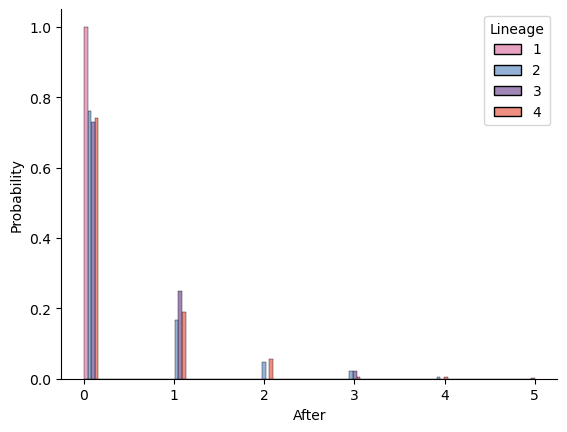

In [39]:
LinToColor_Dict = {1: "#DF83AC",
                   2: "#7098CB",
                   3: "#815D9F",
                   4: "#E76956",
                   # "Other": "white"
                   # "5": "#B67548",
                   # "6": "#6AB79E",
                   # "8": "#E4515B",
                   # "M.bovis": "white",
                  }

sns.histplot(data=df_summary_all_samples,
             x='After',
             hue='Lineage',
             multiple='dodge',
             common_norm=False,
             stat='probability',
             palette=LinToColor_Dict
            )

sns.despine()
plt.show()

In [40]:
def exponential_LRT(df, test_var, group_var='Lineage', min_count=5):
    
    # only keep groups with at least min_count observations
    keep_groups = pd.DataFrame(df.groupby(group_var)[test_var].count()).query(f"{test_var} >= @min_count").index.values
    
    df = df.query(f"{group_var} in @keep_groups")
        
    # Null model: single lambda
    lambda_null = 1 / df[test_var].mean()
    ll_null = np.sum(np.log(lambda_null) - lambda_null * df[test_var])
    
    params_dict = {'Full': lambda_null}

    # Full model: separate lambda per group
    ll_full = 0
    for g, group_df in df.groupby(group_var):
        lambda_g = 1 / group_df[test_var].mean()
        print(f"λ for lineage {g} = {lambda_g}")
        ll_full += np.sum(np.log(lambda_g) - lambda_g * group_df[test_var])
        params_dict[g] = lambda_g

    # Likelihood ratio test
    LR = 2 * (ll_full - ll_null)
    p_value = st.chi2.sf(LR, df=df[group_var].nunique() - 1)
    
    print(f"λ for full = {lambda_null}")

    print(f"\nLikelihood ratio test statistic: {LR:.3f}")
    print(f"P-value: {p_value:.4g}")
    
    return params_dict

In [41]:
lambda_params_dict = exponential_LRT(df_summary_all_samples, 'After', min_count=5)

λ for lineage 2 = 2.8818897637795278
λ for lineage 3 = 3.2
λ for lineage 4 = 2.78448275862069
λ for full = 2.8565891472868215

Likelihood ratio test statistic: 0.837
P-value: 0.658


In [42]:
samples_with_differences = df_compare.query("After != GroundTruth").SampleID.unique()

for sample in samples_with_differences:
    
    if sample not in ['MFS-325', 'MFS-326']:
        
        df_gtf = pd.read_csv(f"{personal_ref_dir}/{sample}/assembly/H37Rv.liftoff.gff_polished", sep='\t', header=None, comment='#')
    
        ground_truth_pos = df_confusion_matrix.query("SampleID==@sample").dropna(subset='POS').POS.unique()
        H37Rv_detected_pos = df_indels_H37Rv.query("SampleID==@sample").POS.unique()

        # diff_pos = list(set(ground_truth_pos).symmetric_difference(H37Rv_detected_pos))
        
        FP_pos = list(set(H37Rv_detected_pos) - set(ground_truth_pos))
        FN_pos = list(set(ground_truth_pos) - set(H37Rv_detected_pos))
        
        if len(FP_pos) > 0:
            FP_AFs = df_indels_H37Rv.query("SampleID==@sample & POS in @FP_pos").AF_Adj.values
            # print(f"{sample} FP: {','.join(FP_AFs.astype(str))}")
            
            for pos in FP_pos:
                region = h37Rv_coords_dict[pos]
                
                if 'NC' in region:
                    start = h37Rv_coords.query("region==@region").pos.min()
                    end = h37Rv_coords.query("region==@region").pos.max()
                    upstream_gene = h37Rv_genes.query("End==@start-1").Symbol.values[0]
                    downstream_gene = h37Rv_genes.query("Start==@end+1").Symbol.values[0]
                    
                    start = df_gtf.loc[df_gtf[8].str.contains(upstream_gene)][4].values[0]
                    end = df_gtf.loc[df_gtf[8].str.contains(downstream_gene)][3].values[0]
                    
                    # print(sample, f"{upstream_gene}-{downstream_gene}", start, end)
                    # print(f'bcftools filter -i "POS >= @start & POS <= @end" {personal_ref_dir}/{sample}/freebayes/{sample}.vcf')
                else:
                    # start = h37Rv_genes.query("Symbol==@region").Start.values[0]
                    # end = h37Rv_genes.query("Symbol==@region").End.values[0]
                    
                    start = df_gtf.loc[df_gtf[8].str.contains(region)][3].values[0]
                    end = df_gtf.loc[df_gtf[8].str.contains(region)][4].values[0]
                    
                    # print(sample, region, start, end)
            
                print(f'bcftools filter -i "POS >= {start} & POS <= {end}" {personal_ref_dir}/{sample}/freebayes/{sample}.vcf')
                
        if len(FN_pos) > 0:
            FN_AFs = df_indels_H37Rv.query("SampleID==@sample & POS in @FN_pos").AF_Adj.values
            print(f"{sample} FN: {','.join(FN_AFs.astype(str))}")

        # print(sample, df_confusion_matrix.query("SampleID==@sample").query("POS in @diff_pos").AF.values)
        # print(sample, df_indels_H37Rv.query("SampleID==@sample & POS in @diff_pos").AF.values)

bcftools filter -i "POS >= 80450 & POS <= 81033" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-132/freebayes/MFS-132.vcf
bcftools filter -i "POS >= 4167436 & POS <= 4168697" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-315/freebayes/MFS-315.vcf
bcftools filter -i "POS >= 3008281 & POS <= 3008943" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-395/freebayes/MFS-395.vcf
bcftools filter -i "POS >= 3722252 & POS <= 3723133" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-395/freebayes/MFS-395.vcf
bcftools filter -i "POS >= 3453742 & POS <= 3454751" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-429/freebayes/MFS-429.vcf
bcftools filter -i "POS >= 854318 & POS <= 854427" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-3/freebayes/MFS-3.vcf
bcftools filter -i "POS >= 1116068 & POS <= 1117144" /n/data1/hms/dbmi/farhat/Sanjana/TRUST_aln_personal_assembly/MFS-56/freebayes/MFS-56.vcf
bcft

In [43]:
# # these are true. They just get messed up with the vcfwave stuff
# df_compare.loc[df_compare['SampleID'].isin(['MFS-325', 'MFS-326']), 'GroundTruth'] += 1

# # manually checked that these are all real, just due to AF ~5% or slightly below. Only one variant for MFS-395 (3721989) is real. The other is not
# df_compare.loc[df_compare['SampleID'].isin(['MFS-132', 'MFS-3', 'MFS-56', 'MFS-675']), 'GroundTruth'] += 1                                            
# df_compare.loc[df_compare['SampleID'].isin(['MFS-395']), 'GroundTruth'] += 2                                           

# df_compare.query("After != GroundTruth").sort_values('SampleID')

In [5]:
noncoding_regions = h37Rv_coords.query("region.str.contains('NC')").region.unique()
noncoding_regions_flanking_genes = {}

for region in noncoding_regions:
    
    # increment and decrement to get the start and end of the surrounding regions
    start = df_noncoding_regions.query("Region==@region").Start.values[0] - 1
    end = df_noncoding_regions.query("Region==@region").End.values[0] + 1
    
    upstream_gene = h37Rv_genes.query("End==@start").Symbol.values[0]
    
    if end <= len(h37Rv_seq):
        downstream_gene = h37Rv_genes.query("Start==@end").Symbol.values[0]
    else:
        downstream_gene = ''
    
    noncoding_regions_flanking_genes[region] = f"{upstream_gene},{downstream_gene}"
        
# add flanking genes for the intergenic variants
df_indels_H37Rv[['Gene1', 'Gene2']] = df_indels_H37Rv['Region'].map(noncoding_regions_flanking_genes).str.split(',', expand=True)

In [6]:
# add start and end to get midpoints for plotting and the boundaries for the enrichment test
for i, row in df_indels_H37Rv.iterrows():
    
    region = row['Region']

    if region in h37Rv_regions.Name.values:
        start = h37Rv_regions.query("Name==@region").Start.values[0]
        end = h37Rv_regions.query("Name==@region").Stop.values[0]

    elif 'NC' in region:
        start = h37Rv_coords.query("region==@region").pos.min()
        end = h37Rv_coords.query("region==@region").pos.max()
        
    df_indels_H37Rv.loc[i, ['Start', 'End']] = [start, end]
    
df_indels_H37Rv[['Start', 'End']] = df_indels_H37Rv[['Start', 'End']].astype(int)

In [7]:
# get length change to determine frameshift vs. inframe
df_indels_H37Rv['Length_Change'] = np.abs(df_indels_H37Rv.REF.str.len() - df_indels_H37Rv.ALT.str.len())

In [47]:
df_indels_H37Rv.loc[(df_indels_H37Rv['ALT'].str.len() > df_indels_H37Rv['REF'].str.len()) & (df_indels_H37Rv['Length_Change'] % 3 == 0) & (~df_indels_H37Rv['Region'].str.startswith('NC')), 'Variant_Type'] = 'Inframe insertion'

df_indels_H37Rv.loc[(df_indels_H37Rv['REF'].str.len() > df_indels_H37Rv['ALT'].str.len()) & (df_indels_H37Rv['Length_Change'] % 3 == 0) & (~df_indels_H37Rv['Region'].str.startswith('NC')), 'Variant_Type'] = 'Inframe deletion'

df_indels_H37Rv.loc[(df_indels_H37Rv['Length_Change'] % 3 != 0) & (~df_indels_H37Rv['Region'].str.startswith('NC')), 'Variant_Type'] = 'Frameshift'

df_indels_H37Rv.loc[df_indels_H37Rv['Region'].str.startswith('NC'), 'Variant_Type'] = 'Intergenic'

In [96]:
df_indels_H37Rv.Variant_Type.value_counts(dropna=False)

Variant_Type
Frameshift           172
Inframe deletion      37
Intergenic            35
Inframe insertion     14
Name: count, dtype: int64

In [97]:
172/len(df_indels_H37Rv)

0.6666666666666666

In [443]:
df_indels_H37Rv.query("Variant_Type == 'Intergenic'").Length_Change.median()

1.0

In [444]:
df_indels_H37Rv.query("Variant_Type=='Frameshift'").Region.value_counts()

Region
devR       12
Rv2690c    10
sugI       10
ceoC       10
pirG        7
           ..
mas         1
Rv2715      1
Rv0051      1
Rv2962c     1
mutA        1
Name: count, Length: 87, dtype: int64

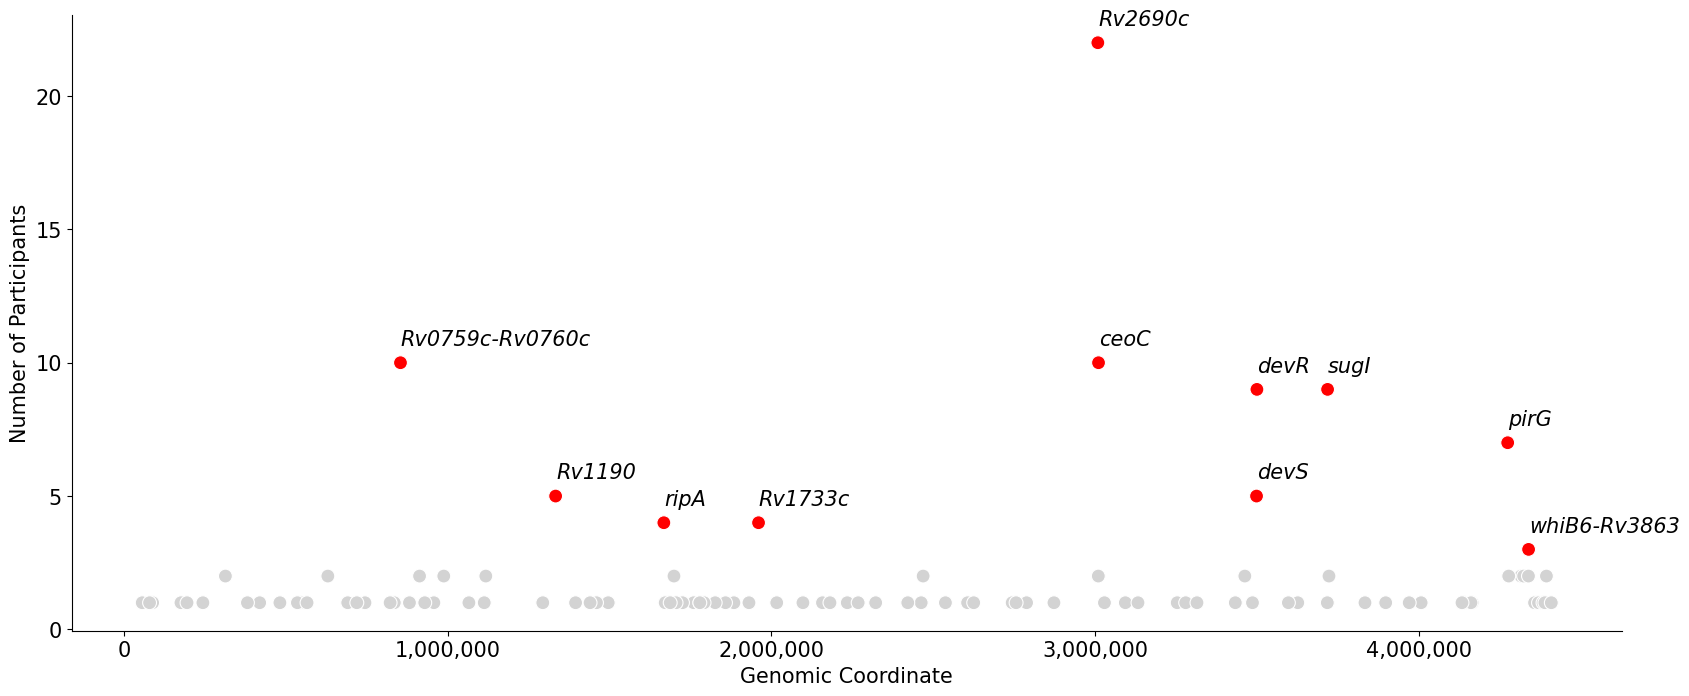

In [451]:
df_indels_grouped_by_region['Midpoint'] = np.mean([df_indels_grouped_by_region['Start'], df_indels_grouped_by_region['End']], axis=0)

y_axis_var = 'Count'
# y_axis_var = 'Fold_Enrichment'
hue_thresh = 3

df_indels_grouped_by_region.loc[df_indels_grouped_by_region[y_axis_var] >= hue_thresh, 'Significant'] = 1
df_indels_grouped_by_region.loc[df_indels_grouped_by_region[y_axis_var] < hue_thresh, 'Significant'] = 0

font_size = 15

fig, ax = plt.subplots(figsize=(20, 8))

sns.scatterplot(data=df_indels_grouped_by_region,
                x='Midpoint',
                y=y_axis_var,
                hue='Significant',
                palette={1: 'red', 0: 'lightgray'},
                legend=False,
                ax=ax,
                s=100
               )

for i, row in df_indels_grouped_by_region.query("Significant==1").iterrows():
    
    if 'NC' in row['Region']:
        name = f"{row['Gene1']}-{row['Gene2']}"
    else:
        name = row['Region']
    
    plt.text(row['Midpoint']+1000, row[y_axis_var]+0.5, name, fontsize=font_size, ha='left', va='bottom', rotation=0,  style='italic')

# ax.ticklabel_format(style='plain', axis='x')
from matplotlib.ticker import StrMethodFormatter

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

sns.despine()

ax.set_xticklabels(ax.get_xticklabels(), fontsize=font_size)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=font_size)

plt.xlabel('Genomic Coordinate', fontsize=font_size)
plt.ylabel('Number of Participants', fontsize=font_size)

plt.savefig("../results/figures/indels_by_region.svg", bbox_inches='tight')

# Indels in Drug Resistance Regions

In [52]:
genes_lst = ['katG', 'inhA', 'pncA']
df_indels_H37Rv.query("Region in @genes_lst | Gene1 in @genes_lst | Gene2 in @genes_lst")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Coll2014,F2,Lineage,Region,Start,End,Length_Change,Variant_Type,Gene1,Gene2


In [398]:
INH_resistance_genes_lst = ['NC_1160', 'NC_1161', 'katG', 'fabG1', 'inhA'] + list(df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("drug=='Isoniazid'").gene.unique())

pos_lst = []
flank = 500

for gene in INH_resistance_genes_lst:
    if gene in h37Rv_regions.Name.values:
        pos_lst += list(np.arange(h37Rv_regions.query("Name==@gene")['Start'].values[0]-flank, h37Rv_regions.query("Name==@gene")['Stop'].values[0]+flank))
    else:
        pos_lst += list(h37Rv_coords.query("region==@gene").pos.values)

df_indels_H37Rv_all.query("POS in @pos_lst").drop_duplicates(subset='POS')

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Lineage,Region,HT_Region,phase_variant,Gene1,Gene2,Start,End,Indel,Sampling_Week
5,2153725,CTCATCCCCGTCTCG,C,0.82199,157,191,280.0,280.0,1.0,MFS-872,...,NaN,Rv1907c,1,0,NaN,NaN,NaN,NaN,2153725_CTCATCCCCGTCTCG,8
1307,1673277,C,CT,1.00000,300,300,NaN,NaN,1.0,MFS-788,...,NaN,Rv1482c,0,0,NaN,NaN,NaN,NaN,1673277_C,4


In [400]:
df_indels_H37Rv_all.query("Region in @INH_resistance_genes_lst")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Lineage,Region,HT_Region,phase_variant,Gene1,Gene2,Start,End,Indel,Sampling_Week


In [393]:
df_who_variants.query("drug=='Isoniazid'").gene.unique()

array(['ahpC', 'dnaA', 'glpK', 'hadA', 'inhA', 'katG', 'mshA', 'ndh',
       'Rv0010c', 'Rv1129c', 'Rv1258c', 'Rv2752c'], dtype=object)

In [399]:
EMB_resistance_genes_lst = list(df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("drug=='Ethambutol'").gene.unique())

pos_lst = []
flank = 500

for gene in EMB_resistance_genes_lst:
    pos_lst += list(np.arange(h37Rv_regions.query("Name==@gene")['Start'].values[0]-flank, h37Rv_regions.query("Name==@gene")['Stop'].values[0]+flank))

df_indels_H37Rv_all.query("POS in @pos_lst")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Lineage,Region,HT_Region,phase_variant,Gene1,Gene2,Start,End,Indel,Sampling_Week


In [397]:
PZA_resistance_genes_lst = list(df_who_variants.loc[df_who_variants['FINAL CONFIDENCE GRADING'].str.contains('Assoc w R')].query("drug=='Pyrazinamide'").gene.unique())

pos_lst = []
flank = 500

for gene in PZA_resistance_genes_lst:
    pos_lst += list(np.arange(h37Rv_regions.query("Name==@gene")['Start'].values[0]-flank, h37Rv_regions.query("Name==@gene")['Stop'].values[0]+flank))

df_indels_H37Rv_all.query("POS in @pos_lst")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Lineage,Region,HT_Region,phase_variant,Gene1,Gene2,Start,End,Indel,Sampling_Week
533,2289365,CG,C,0.975862,283,290,NaN,NaN,0.975862,MFS-848,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,1
2683,2289365,CG,C,0.979661,289,295,NaN,NaN,0.979661,MFS-790,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,4
4242,2289365,CG,C,0.975265,276,283,NaN,NaN,0.975265,MFS-554,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,7
4442,2289365,CG,C,1.000000,230,230,NaN,NaN,1.000000,MFS-557,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,1
4541,2289365,CG,C,0.972696,285,293,NaN,NaN,0.972696,MFS-574,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,1
4845,2289365,CG,C,0.979661,289,295,NaN,NaN,0.979661,MFS-269,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,1
8686,2289365,CG,C,0.988889,267,270,NaN,NaN,0.988889,MFS-392,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,8
8785,2289365,CG,C,0.996587,292,293,NaN,NaN,0.996587,MFS-391,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,1
11019,2289365,CG,C,0.987705,241,244,NaN,NaN,0.987705,MFS-180,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,2
12988,2289365,CG,C,0.965608,365,378,NaN,NaN,0.965608,MFS-135,...,NaN,Rv2044c,1,1,NaN,NaN,NaN,NaN,2289365_CG,1


# Do any samples have unfixed SNVs and indels in the same gene / region?

In [527]:
df_unfixed_SNVs = pd.read_csv("unfixed_SNVs_all.csv")
len(df_unfixed_SNVs)

1589

In [528]:
len(df_indels_H37Rv)

258

In [529]:
def get_reads_supporting_variant(bam_file, pos, ref, alt):
    
    reads_supporting = []
    
    indel_length = abs(len(ref) - len(alt))
    
    if len(alt) > len(ref):
        search_string = 'I'
        search_val = 1
    else:
        search_string = 'D'
        search_val = 2

    if indel_length == 0:
        variant_type = 'SNV'
    else:
        variant_type = 'indel'
    
    for pileupcolumn in bam.pileup('Chromosome', pos-1, pos, truncate=True, min_base_quality=30):

        for pileupread in pileupcolumn.pileups:
            
            aln = pileupread.alignment
            
            if not aln.is_supplementary and not aln.is_secondary and aln.is_proper_pair:

                if variant_type == 'SNV':

                    # skip deletions and reference skips (meaning there is no aligned base at this site bc there is a deletion)
                    if not pileupread.is_del and not pileupread.is_refskip:
                        base = aln.query_sequence[pileupread.query_position]

                        if base == alt:
                            reads_supporting.append(aln.query_name)
                
                else:
                    indel_cigar_length = sum(length for (op, length) in (aln.cigartuples or []) if op == search_val and length == indel_length)

                    if indel_cigar_length == indel_length:
                        reads_supporting.append(aln.query_name)
                        
    return reads_supporting

In [534]:
for sample in df_unfixed_SNVs.SampleID.unique():
    
    pid = df_unfixed_SNVs.query("SampleID==@sample").pid.values[0]
    
    regions_with_SNVs_and_indels = list(set(df_unfixed_SNVs.query("SampleID==@sample").Region).intersection(df_indels_H37Rv.query("SampleID==@sample").Region))
    
    if len(regions_with_SNVs_and_indels) > 0:
        # print(sample, regions_with_SNVs_and_indels)
        
        bam_file = f"{H37Rv_ref_dir}/{sample}/bam/{sample}.dedup.bam"
        bam = pysam.AlignmentFile(bam_file, "rb")
            
        for region in regions_with_SNVs_and_indels:
            
            SNV_pos_lst = list(df_unfixed_SNVs.query("SampleID==@sample & Region==@region").POS.values)
            indel_pos_lst = list(df_indels_H37Rv.query("SampleID==@sample & Region==@region").POS.values)
            
            pos_combinations = list(itertools.product(SNV_pos_lst, indel_pos_lst))

            # pos_diff = np.abs(SNV_pos - indel_pos)
                
            for i, (SNV_pos, indel_pos) in enumerate(pos_combinations):
                
                # short reads are 150 base pairs. So only check read overlap for variants within 100 bp. Others won't have any chance of having reads supporting both because they're too far apart
                if abs(SNV_pos - indel_pos) <= 100:
                                
                    df_SNV = df_unfixed_SNVs.query("SampleID==@sample & POS==@SNV_pos")
                    df_indel = df_indels_H37Rv.query("SampleID==@sample & POS==@indel_pos")
                    
                    SNV_reads = get_reads_supporting_variant(bam_file, SNV_pos, df_SNV['REF'].values[0], df_SNV['ALT'].values[0])
                    indel_reads = get_reads_supporting_variant(bam_file, indel_pos, df_indel['REF'].values[0], df_indel['ALT'].values[0])
                    
                    reads_supporting_both = list(set(SNV_reads).intersection(indel_reads))
                    
                    if len(reads_supporting_both) > 0:
                        print(f"{pid}, {sample}: {SNV_pos} and {indel_pos} in {region} are both supported by {len(reads_supporting_both)} reads")
                    else:
                        print(f"{pid}, {sample}: {SNV_pos} and {indel_pos} in {region} are NOT supported by the same reads")

T0220, MFS-129: 3717108 and 3717127 in sugI are NOT supported by the same reads
T0270, MFS-190: 3008745 and 3008747 in Rv2690c are both supported by 15 reads
T0288, MFS-306: 4338594 and 4338595 in NC_2982 are both supported by 125 reads
T0284, MFS-325: 4338594 and 4338595 in NC_2982 are both supported by 204 reads
T0284, MFS-326: 4338594 and 4338595 in NC_2982 are both supported by 175 reads
T0343, MFS-420: 3717105 and 3717125 in sugI are NOT supported by the same reads
T0343, MFS-421: 932280 and 932279 in Rv0836c are NOT supported by the same reads
T0354, MFS-435: 4393590 and 4393583 in mutT4 are both supported by 1 reads
T0354, MFS-436: 4393590 and 4393583 in mutT4 are NOT supported by the same reads
T0203, MFS-757: 3717105 and 3717125 in sugI are NOT supported by the same reads
T0417, MFS-800: 3499052 and 3499071 in devS are NOT supported by the same reads
T0417, MFS-800: 3499111 and 3499071 in devS are NOT supported by the same reads


In [531]:
df_indels_H37Rv.Region.value_counts()

Region
Rv2690c    28
NC_597     12
devR       12
sugI       11
ceoC       10
           ..
Rv1101c     1
espK        1
espJ        1
mez         1
mutA        1
Name: count, Length: 122, dtype: int64

In [535]:
df_indels_H37Rv.POS.value_counts()

POS
3008060    17
854252     11
3010354     9
1333661     6
4338595     4
           ..
3255381     1
381842      1
3499465     1
1826288     1
1683788     1
Name: count, Length: 180, dtype: int64

In [541]:
h37Rv_genes.query("Symbol=='Rv0759c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
783,783,CDS,853825,854157,-,0.0,Rv0759c,Rv0759c,Function unknown,Conserved hypothetical protein,...,P9WML3,ML2237,MMAR_4940,MSMEG_5871,Mb0782c,NaN,NaN,NaN,NaN,NaN


In [540]:
df_indels_H37Rv.query("Gene1=='Rv0759c'")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,F2,Lineage,Region,Gene1,Gene2,Start,End,Length_Change,Variant_Type,Sampling_Week
30,854252,GC,G,0.084034,30,357,36.0,353.0,0.101983,MFS-752,...,0.012978,4.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,4
36,854252,GC,G,0.405498,118,291,135.0,327.0,0.412844,MFS-758,...,0.011056,2.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,1
37,854252,GC,G,0.238095,55,231,66.0,268.0,0.246269,MFS-759,...,0.011409,2.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,5
40,854252,GC,G,0.144118,49,340,55.0,336.0,0.163690,MFS-760,...,0.009735,4.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,7
51,854252,GC,G,0.858407,194,226,213.0,245.0,0.869388,MFS-681,...,0.004263,4.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,1
52,854252,GC,G,0.825776,346,419,380.0,456.0,0.833333,MFS-793,...,0.003493,4.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,4
53,854252,GC,G,0.716263,207,289,225.0,306.0,0.735294,MFS-795,...,0.019587,4.0,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,8
157,854252,G,GC,0.068841,19,276,21.0,290.0,0.072414,MFS-437,...,0.006793,4,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,1
192,854252,GC,G,0.933054,223,239,243.0,257.0,0.945525,MFS-30,...,0.009991,2,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,1
205,854252,GC,G,0.936842,267,285,296.0,315.0,0.939683,MFS-3,...,0.008362,2,NC_597,Rv0759c,Rv0760c,854158,854266,1,Intergenic,1


In [96]:
df_indels_H37Rv.query("POS==3008060")[['SampleID', 'POS', 'REF', 'ALT', 'AF', 'Indel_Support', 'Total_Reads', 'Coll2014',]]

,SampleID,POS,REF,ALT,AF,Indel_Support,Total_Reads,Coll2014
20,MFS-394,3008060,TCGC,T,0.261745,94.0,319.0,4.3.2.1
44,MFS-673,3008060,TCGC,T,0.053459,22.0,311.0,2.2.1.1
48,MFS-792,3008060,TCGC,T,0.828571,296.0,353.0,4.3.3
88,MFS-697,3008060,TCGC,T,0.060686,24.0,367.0,4.3.4.1
98,MFS-430,3008060,TCGC,T,0.238255,85.0,311.0,4.3.3
100,MFS-431,3008060,TCGC,T,0.283186,69.0,227.0,4.3.3
106,MFS-417,3008060,TCGC,T,0.177778,67.0,323.0,4.4.1.1
115,MFS-427,3008060,TCGC,T,0.378049,117.0,265.0,4.3.3
145,MFS-392,3008060,TCGC,T,0.277592,91.0,305.0,3.1.1
147,MFS-482,3008060,TCGC,T,0.077206,30.0,281.0,4.3.3


In [98]:
h37Rv_genes.query("Symbol=='Rv2690c'")

,Gene_Ind,Feature,Start,End,Strand,Frame,H37rv_GeneID,Symbol,Function,Product,...,SWISS-MODEL,Orthologues M. leprae,Orthologues M. marinum,Orthologues M. smegmatis,Orthologues M. bovis,Orthologues M. lepromatosis,Orthologues M. tuberculosis,Orthologues M. abscessus,Orthologues M. haemophilum,Orthologues M. orygis
2765,2765,CDS,3007236,3009209,-,0.0,Rv2690c,Rv2690c,Unknown,Probable conserved integral membrane alanine a...,...,I6Y1H7,NaN,MMAR_2024,MSMEG_2772,Mb2709c,NaN,NaN,NaN,NaN,NaN


# Longitudinal Changes in Unfixed Indels

In [49]:
def convert_variants_to_matrices(df_variants, variant_col, AF_col='AF', baseline_only=False):
    
    variant_matrix = []

    # fixed_AF_thresh = 1.2
    # baseline samples only, so if the column isn't there, assign 1. If doing longitudinal analysis, the Paired_Sample_Num column needs to be added before!
    if baseline_only and 'Paired_Sample_Num' not in df_variants.columns:
        df_variants['Paired_Sample_Num'] = 1

    # use df_lowAF_variants because the signal for low frequency variants gets drowned out by tons of fixed SNPs
    for pid in df_variants.pid.unique():

        single_pid_matrix = df_variants.query("pid==@pid").pivot(index='Paired_Sample_Num', columns=variant_col, values=AF_col)
        
        single_pid_matrix.index = pid + '_' + single_pid_matrix.index.astype(str)

        # variant_matrix.append(single_pid_matrix[keep_variants])
        variant_matrix.append(single_pid_matrix)

    variant_matrix = pd.concat(variant_matrix).fillna(0)

    sample_1_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_1')]
    
    # remove the suffixes from the indexes
    sample_1_variants.index = sample_1_variants.index.str.split('_').str[0]
    
    if not baseline_only:
        sample_2_variants = variant_matrix.loc[variant_matrix.index.str.endswith('_2')]
        sample_2_variants.index = sample_2_variants.index.str.split('_').str[0]    

        # make sure they have the same samples
        all_pids = np.sort(list(set(sample_1_variants.index).union(sample_2_variants.index)))

        missing_pids_sample1 = list(set(all_pids) - set(sample_1_variants.index))
        missing_pids_sample2 = list(set(all_pids) - set(sample_2_variants.index))

        sample_1_variants = pd.concat([sample_1_variants,
                                   pd.DataFrame(index=missing_pids_sample1, columns=sample_1_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        sample_2_variants = pd.concat([sample_2_variants,
                                   pd.DataFrame(index=missing_pids_sample2, columns=sample_2_variants.columns).fillna(0)
                                  ]).loc[all_pids]

        variant_differences = sample_2_variants - sample_1_variants
        print(variant_differences.shape)

        return sample_1_variants, sample_2_variants, variant_differences
    
    else:
        print(sample_1_variants.shape)
        return sample_1_variants

In [8]:
AF_min = 0.05
AF_max = 0.95

df_fixed_indels_H37Rv = pd.concat([pd.read_csv("variantDetector/unfixed_indels.csv").query("AF > 0.95 | AF_Adj > @AF_max"),
                                   pd.read_csv("variantDetector/fixed_indels.csv") # these are the indels that started out with AF > 0.95
                                  ]).drop_duplicates(subset=['SampleID', 'POS'], keep='first') # drop duplicates because fixed indels will be in both dataframes

# fixed_indels.csv is NA for the AF_Adj column, so fill it in
df_fixed_indels_H37Rv['AF_Adj'] = df_fixed_indels_H37Rv['AF_Adj'].fillna(df_fixed_indels_H37Rv['AF'])

df_fixed_indels_H37Rv['Region'] = df_fixed_indels_H37Rv['POS'].map(h37Rv_coords_dict)

df_fixed_indels_H37Rv[['Gene1', 'Gene2']] = df_fixed_indels_H37Rv['Region'].map(noncoding_regions_flanking_genes).str.split(',', expand=True)

len(df_fixed_indels_H37Rv)

56669

In [9]:
df_longitudinal_pids = pd.read_csv(f"{TRUST_data_dir}/longitudinal_pids_WGS_data.csv")
print(f"{df_longitudinal_pids.pid.nunique()} pids with longitudinal sequencing")

pids_with_low_F2 = pd.DataFrame(df_longitudinal_pids.query("F2 <= @F2_max").groupby('pid')['SampleID'].nunique()).query("SampleID > 1").index.values

# # additionally require pids to have had the EXACT same lineage
pids_with_same_lineage = pd.DataFrame(df_longitudinal_pids.groupby('pid')['mix_phylotypes'].nunique()).query("mix_phylotypes == 1").index.values
pids_with_same_lineage = np.unique(list(pids_with_same_lineage))

pids_with_same_lineage_and_low_F2 = list(set(pids_with_low_F2).intersection(pids_with_same_lineage))
print(f"{len(pids_with_same_lineage_and_low_F2)} pids have F2 ≤ {F2_max} and matching lineages between timepoints")

df_longitudinal_pids['Sampling_Interval'] = df_longitudinal_pids.groupby('pid')['Sampling_Week'].transform(lambda x: np.max(x) - np.min(x))
print(f"    Sampling interval: median = {df_longitudinal_pids.Sampling_Interval.median()}, mean = {df_longitudinal_pids.Sampling_Interval.mean()}")

325 pids with longitudinal sequencing
285 pids have F2 ≤ 0.03 and matching lineages between timepoints
    Sampling interval: median = 6.0, mean = 5.483076923076923


In [10]:
# combine with fixed variants
df_indels_H37Rv_all = pd.concat([df_indels_H37Rv, df_fixed_indels_H37Rv]).drop_duplicates()

if 'Sampling_Week' in df_indels_H37Rv_all.columns:
    del df_indels_H37Rv_all['Sampling_Week']

# add column combining POS, REF, and ALT
df_indels_H37Rv_all['Indel'] = df_indels_H37Rv_all['POS'].astype(str) + '_' + df_indels_H37Rv_all['REF']# + '_' + df_indels_H37Rv_all['ALT']

# subset to the ones with longitudinal sequencing (2 samples, F2 ≤ 0.03, and matching lineages)
df_indels_H37Rv_longitudinal = df_indels_H37Rv_all.merge(df_longitudinal_pids.query("pid in @pids_with_same_lineage_and_low_F2")[['pid', 'Paired_Sample_Num', 'SampleID']], on=['SampleID', 'pid'])

df_indels_H37Rv_all = df_indels_H37Rv_all.merge(df_trust_patients[['pid', 'SampleID', 'Sampling_Week']])

print(len(df_indels_H37Rv_all), df_indels_H37Rv_all.pid.nunique())
print(len(df_indels_H37Rv_longitudinal), df_indels_H37Rv_longitudinal.pid.nunique())

56927 418
44345 285


In [11]:
HT_len = 7
HT_regions = pd.read_csv("~/MtbLongitudinalDiversity/data/nucleotide_runs_all_lengths.csv").query("Length >= @HT_len")

print(f"Min HT length: {HT_regions.Length.min()}")
print(f"Max HT length: {HT_regions.Length.max()}")

HT_pos = []

for i, row in HT_regions.iterrows():
    # subtract 1 from start because many indels will be listd at the previous position and ins something
    HT_pos += list(np.arange(row['POS'] - 1, row['POS'] + row['Length']))

if 'HT_Region' in df_indels_H37Rv_all.columns:
    del df_indels_H37Rv_all['HT_Region']
    
if 'phase_variant' in df_indels_H37Rv_all.columns:
    del df_indels_H37Rv_all['phase_variant']
    
df_indels_H37Rv_all['HT_Region'] = df_indels_H37Rv_all['POS'].isin(HT_pos).astype(int)

# the HT pos could be one after the insertion because the insertion site will be right before it
df_indels_H37Rv_all.loc[(df_indels_H37Rv_all['REF'].str.len() < df_indels_H37Rv_all['ALT'].str.len()) & (df_indels_H37Rv_all['POS'].isin(np.array(HT_pos) - 1)), 'HT_Region'] = 1

df_indels_H37Rv_all = df_indels_H37Rv_all.reset_index(drop=True)

for i, row in df_indels_H37Rv_all.query("HT_Region==1").iterrows():
    
    if len(row['REF']) > len(row['ALT']):
        diff_nucs = row['REF'][1:]
    else:
        diff_nucs = row['ALT'][1:]
        
    # print(row['REF'], row['ALT'], diff_nucs)
                
    if len(np.unique(list(diff_nucs))) == 1:
        df_indels_H37Rv_all.loc[i, 'phase_variant'] = 1
 
df_indels_H37Rv_all['phase_variant'] = df_indels_H37Rv_all['phase_variant'].fillna(0).astype(int)

assert len(df_indels_H37Rv_all.query("HT_Region==0 & phase_variant==1")) == 0

assert sum(pd.isnull(df_indels_H37Rv_all['HT_Region'])) == 0
assert sum(pd.isnull(df_indels_H37Rv_all['phase_variant'])) == 0

Min HT length: 7
Max HT length: 9


In [12]:
len(df_indels_H37Rv_all), len(df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max"))

(56927, 258)

In [13]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max").query("phase_variant==1").pid.nunique()

26

In [23]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max").query("phase_variant==1").Lineage.value_counts()

Lineage
2      11
4.0     7
2.0     5
4       3
3.0     2
Name: count, dtype: int64

In [60]:
sample_1_indels, sample_2_indels, indel_differences = convert_variants_to_matrices(df_indels_H37Rv_longitudinal,
                                                                                  'Indel',
                                                                                   AF_col='AF_Adj'
                                                                                  )

sample_1_indels_baseline = convert_variants_to_matrices(df_indels_H37Rv_all.query("Sampling_Week <= 2").sort_values(['pid', 'Sampling_Week', 'SampleID']).drop_duplicates(subset='pid', keep='first').reset_index(drop=True),
                                                       'Indel',
                                                        AF_col='AF_Adj',
                                                        baseline_only=True
                                                       )

(285, 985)
(395, 103)


In [100]:
sample_1_indels_long = sample_1_indels.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample1'})
sample_2_indels_long = sample_2_indels.reset_index().melt(id_vars='index').rename(columns={'index': 'pid', 'value': 'Sample2'})

unfixed_indels_wide = sample_1_indels_long.merge(sample_2_indels_long)

# exclude variants absent or fixed at both timepoints
unfixed_indels_wide = unfixed_indels_wide.query("~(Sample1==0 & Sample2==0) & ~(Sample1 > @AF_max & Sample2 > @AF_max)")

# keep only variants unfixed at either timepoint
unfixed_indels_wide = unfixed_indels_wide.query("(Sample1 >= @AF_min & Sample1 <= @AF_max) | (Sample2 >= @AF_min & Sample2 <= @AF_max)")

unfixed_indels_wide = unfixed_indels_wide.merge(df_indels_H37Rv_all[['Indel', 'Region', 'Gene1', 'Gene2', 'phase_variant']].drop_duplicates(), how='left')

# unfixed_indels_wide = unfixed_indels_wide.melt(id_vars=['pid', 'Indel', 'Region', 'Gene1', 'Gene2'],
#                                            value_vars=["BL", "FU"],
#                                            var_name="Timepoint",
#                                            value_name="Value"
#                                           )

unfixed_indels_wide['Diff'] = unfixed_indels_wide['Sample2'] - unfixed_indels_wide['Sample1']
unfixed_indels_wide['Abs_Diff'] = np.abs(unfixed_indels_wide['Diff'])

unfixed_indels_wide.loc[unfixed_indels_wide['Sample1'] <= 0.5, 'Sample1_MinorAF'] = unfixed_indels_wide['Sample1']
unfixed_indels_wide.loc[unfixed_indels_wide['Sample2'] > 0.5, 'Sample2_MinorAF'] = 1 - unfixed_indels_wide['Sample2']
unfixed_indels_wide.loc[unfixed_indels_wide['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - unfixed_indels_wide['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
unfixed_indels_wide.loc[unfixed_indels_wide['Sample1'] <= 0.5, 'Sample2_MinorAF'] = unfixed_indels_wide['Sample2']
unfixed_indels_wide.loc[unfixed_indels_wide['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - unfixed_indels_wide['Sample2']

unfixed_indels_wide['MinorAF_Change'] = unfixed_indels_wide['Sample2_MinorAF'] - unfixed_indels_wide['Sample1_MinorAF']

assert sum(pd.isnull(unfixed_indels_wide['Sample1_MinorAF'])) == 0
assert sum(pd.isnull(unfixed_indels_wide['Sample2_MinorAF'])) == 0

In [102]:
st.ttest_rel(unfixed_indels_wide['Sample1_MinorAF'],
             unfixed_indels_wide['Sample2_MinorAF'],
             alternative='less'
            )

TtestResult(statistic=-5.232774232634965, pvalue=2.3186177853690126e-07, df=179)

In [103]:
st.ttest_rel(unfixed_indels_wide.query("phase_variant==1")['Sample1_MinorAF'],
             unfixed_indels_wide.query("phase_variant==1")['Sample2_MinorAF'],
             alternative='less'
            )

TtestResult(statistic=-1.9970477798908257, pvalue=0.02980469756814497, df=20)

In [96]:
set(unfixed_indels_wide.pid) - set(df_longitudinal_pids.pid)

set()

<Axes: xlabel='MinorAF_Change', ylabel='Count'>

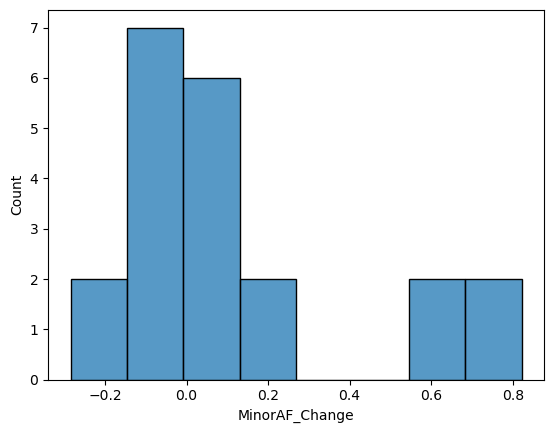

In [108]:
sns.histplot(data=unfixed_indels_wide.query("phase_variant==1"),
             x='MinorAF_Change'
            )

In [109]:
unfixed_indels_wide.query("phase_variant==1").sort_values('MinorAF_Change').query("MinorAF_Change > 0.4")



,pid,Indel,Sample1,Sample2,Region,Gene1,Gene2,phase_variant,Diff,Abs_Diff,Sample1_MinorAF,Sample2_MinorAF,MinorAF_Change
46,T0102,1333661_C,0.955078,0.280788,Rv1190,NaN,NaN,1,-0.674290,0.674290,0.044922,0.719212,0.674290
35,T0090,4323354_C,0.315412,0.993769,NC_2971,Rv3848,espR,1,0.678357,0.678357,0.315412,0.993769,0.678357
141,T0140,4007271_CG,0.726531,0.000000,aspB,NaN,NaN,1,-0.726531,0.726531,0.273469,1.000000,0.726531
8,T0222,854252_GC,0.985222,0.163690,NC_597,Rv0759c,Rv0760c,1,-0.821531,0.821531,0.014778,0.836310,0.821531


In [116]:
st.ttest_rel(unfixed_indels_wide.query("phase_variant==1").sort_values('MinorAF_Change').query("MinorAF_Change <= 0.4")['Sample1_MinorAF'],
             unfixed_indels_wide.query("phase_variant==1").sort_values('MinorAF_Change').query("MinorAF_Change <= 0.4")['Sample2_MinorAF']
            )

TtestResult(statistic=0.03625463448020443, pvalue=0.9715277974285633, df=16)

0.02980469756814497


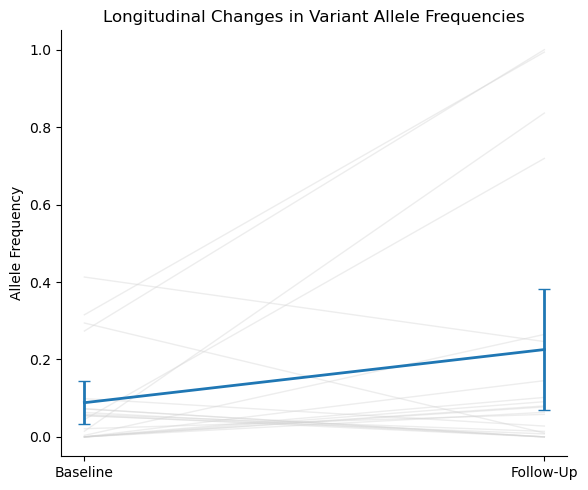

In [104]:
diff_min = 0.05
diff_max = 0.95

AF_min = 0.05

col_1 = 'Sample1_MinorAF'
col_2 = 'Sample2_MinorAF'

df_plot = unfixed_indels_wide.query("phase_variant==1")#.copy()#.query("Region in @enriched_genes") #variant_differences_long.query("Sample1 >= @AF_min & Sample1 <= @AF_max & Sample2 > @AF_max") #variant_differences_long.query("Sample1 != 0 & Sample2 != 0") #variant_differences_long.query("Sample1 != 0 & Sample2 != 0") # variant_differences_long.copy()#

df_plot = df_plot.merge(df_trust_patients[['pid', 'Lineage']].drop_duplicates(), how='left')
df_plot['Lineage'] = df_plot['Lineage'].astype(float).astype(int)

# df_plot = df_plot.query("Abs_Change >= @diff_min & Abs_Change <= @diff_max")

df_plot.loc[df_plot['Sample1'] <= 0.5, 'Sample1_MinorAF'] = df_plot['Sample1']
df_plot.loc[df_plot['Sample1'] > 0.5, 'Sample1_MinorAF'] = 1 - df_plot['Sample1']

# minor AF needs to be relative to what the minor allele at BL is
df_plot.loc[df_plot['Sample1'] <= 0.5, 'Sample2_MinorAF'] = df_plot['Sample2']
df_plot.loc[df_plot['Sample1'] > 0.5, 'Sample2_MinorAF'] = 1 - df_plot['Sample2']

df_plot['MinorAF_Change'] = df_plot['Sample2_MinorAF'] - df_plot['Sample1_MinorAF']

# only unfixed variants at at least one timepoint. Exclude changes from absent to fixed and vice versa
df_plot = df_plot.query(f"(({col_1} >= @AF_min & {col_1} <= @AF_max) | ({col_2} >= @AF_min & {col_2} <= @AF_max))")

stat, pval = st.ttest_rel(df_plot[col_1], 
                          df_plot[col_2], 
                          alternative='less'
                         )
print(pval)

plt.figure(figsize=(6, 5))

# --- 1. Plot all individual paired lines (light gray) ---
for _, row in df_plot.iterrows():
    plt.plot([0, 1], [row[col_1], row[col_2]],
             color="lightgray",
             alpha=0.4,
             linewidth=1
            )

# --- 2. Compute mean and 95% CI ---
means = [df_plot[col_1].mean(), df_plot[col_2].mean()]

# 95% CI using t distribution
ci_bl = st.sem(df_plot[col_1]) * st.t.ppf(0.975, len(df_plot)-1)
ci_fu = st.sem(df_plot[col_2]) * st.t.ppf(0.975, len(df_plot)-1)

cis = [ci_bl, ci_fu]

# --- 3. Overlay mean line in blue ---
plt.plot([0, 1], means, linewidth=2)

# --- 4. Add 95% CI error bars ---
plt.errorbar([0, 1], means, yerr=cis,
             fmt='none',
             capsize=4,
             linewidth=2)

# --- 5. Format axes ---
plt.title(f"Longitudinal Changes in Variant Allele Frequencies")
plt.xticks([0, 1], ["Baseline", "Follow-Up"])
plt.ylabel("Allele Frequency")
plt.tight_layout()
sns.despine()
# plt.savefig("../results/figures/AF_changes_in_enriched_genes.svg")


In [45]:
thresh = 0.05

df_indel_differences_changes = pd.DataFrame(columns = ['Indel', 'AvgChange', 'pval'])

for i, col in enumerate(indel_differences.columns):
    
    sig_indel_differences = indel_differences.loc[(indel_differences[col] >= thresh) | (indel_differences[col] <= -thresh)]
    
    if sig_indel_differences[col].max() > 0:    
        _, pval = st.wilcoxon(sig_indel_differences[col], alternative='two-sided')
    # 0s everywhere
    else:
        pval = np.nan
    
    df_indel_differences_changes.loc[i, :] = [col,
                                              sig_indel_differences[col].mean(),
                                              pval
                                             ]
    
df_indel_differences_changes = df_indel_differences_changes.merge(df_indels_H37Rv_longitudinal[['POS', 'REF', 'ALT', 'Region', 'Indel', 'Gene1', 'Gene2']].drop_duplicates())



In [46]:
df_indel_differences_changes.query("pval <= 0.2").sort_values('pval')

,Indel,AvgChange,pval,POS,REF,ALT,Region,Gene1,Gene2


In [344]:
df_indels_H37Rv_all.query("AF_Adj >= 0.05 & AF_Adj <= 0.95").Indel.value_counts()

Indel
3008060_TCGC    16
1333661_C        6
3010354_T        6
854252_GCC       5
854252_GC        5
                ..
1826288_GA       1
3278566_CTT      1
3028099_T        1
3314854_G        1
1683788_G        1
Name: count, Length: 179, dtype: int64

In [574]:
TRUST_isolate_variants.query("drug=='Pyrazinamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,SampleID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,pid
23253,MFS-637,2289202,A,G,PASS,8287.0,False,1.0,246.0,34.0,...,0.0,0.0,missense_variant,pncA,c.40T>C,p.Cys14Arg,pncA_p.Cys14Arg,Pyrazinamide,1) Assoc w R,T0208


# Indels in the Regions of Interest identified for Phase Variants

Based on Roger's paper and other sources

In [56]:
virulence_genes = h37Rv_genes.query("Functional_Category=='virulence, detoxification, adaptation'").Symbol.values
esx_genes = h37Rv_genes.query("Product.str.contains('ESX')").Symbol.values
esx1_genes = h37Rv_genes.query("Product.str.contains('ESX-1')").Symbol.values

# prpR = Rv1129c
regions_of_interest = ['Rv1129c', 
                       'glpK', 
                       'eccB3', 
                     'espR', 
                       'espA', 
                       'espK',
                     'bioF2', 
                       'ponA1', 
                     'Rv0678',
                     'PPE13',
                     'Rv1373',
                     'PE_PGRS25', # low empirical base pair recall
                     'wag22', # low empirical base pair recall
                     'Rv1894c',
                     'Rv2264c',
                     'lipR',
                     'PPE53', # low empirical base pair recall
                     'Rv3192',
                     'Rv3413c',
                     'B11',  # small regulatory RNA
                      'MTB000058' # alternative name for B11
                    ]

# check for variants in the intergenic regions by checking for variants with downstream_genes in the name. The downstream genes are downstream of the variant,
# which means that variant is upstream of the gene
upstream_genes = ['vapC2', 'Rv0759c', 'lysX', 'Rv2177c', 'Rv3848']
downstream_genes = ['Rv0302', 'Rv0760c', 'infC', 'aroG', 'espR']

full_genes_list = np.unique(regions_of_interest + upstream_genes + downstream_genes + list(virulence_genes) + list(esx_genes) + list(esx1_genes))

len(full_genes_list)

303

In [57]:
gene = 'Rv1190'
df_indels_H37Rv_all.query("Region==@gene & AF_Adj >= 0.05 & AF_Adj <= 0.95").pid

1548     T0102
3172     T0440
7885     T0334
11701    T0031
12327    T0150
12612    T0033
Name: pid, dtype: object

In [107]:
df_indels_H37Rv_all.query("Region==@gene & AF_Adj >= 0.05 & AF_Adj <= 0.95")[['pid', 'SampleID', 'Sampling_Week', 'AF_Adj', 'POS', 'REF', 'ALT']]

,pid,SampleID,Sampling_Week,AF_Adj,POS,REF,ALT
1548,T0102,MFS-740,5,0.280788,1333661,C,CG
3172,T0440,MFS-704,1,0.948980,1333661,C,CGG
7885,T0334,MFS-402,1,0.879699,1333661,C,CGG
11701,T0031,MFS-17,8,0.080000,1333661,C,CG
12327,T0150,MFS-75,6,0.145299,1333661,C,CG
12612,T0033,MFS-18,1,0.901099,1333661,C,CGG


In [100]:
df_trust_patients.query("pid=='T0033'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week
730,T0033,S0033-01,MFS-18,MFS-18_lib45948,NaN,NaN,1.0,375.92,0.99,0.9873,...,0.353703,NaN,0.010461,2.2.1,2.2.1.1.1.i2,2,0.51,375.0,98.577433,1
731,T0033,S0033-05,MFS-19,MFS-19_lib45949,NaN,NaN,1.0,393.71,0.99,0.9863,...,0.353703,NaN,0.010826,2.2.1,2.2.1.1.1.i2,2,0.47,393.0,98.573126,5


In [106]:
df_indels_H37Rv_all.query("AF_Adj > 0.95 & pid in ['T0102', 'T0440', 'T0334', 'T0031', 'T0150', 'T0033'] & POS==1333661")[['pid', 'SampleID', 'Sampling_Week', 'POS', 'REF', 'ALT', 'AF', 'AF_Adj']]

,pid,SampleID,Sampling_Week,POS,REF,ALT,AF,AF_Adj
12750,T0033,MFS-19,5,1333661,C,CGG,0.971963,0.971963
19592,T0102,MFS-739,1,1333661,C,CGG,0.935691,0.955078


In [109]:
df_indels_H37Rv_all.query("pid=='T0102' & POS==1333661")[['pid', 'SampleID', 'Sampling_Week', 'POS', 'REF', 'ALT', 'AF', 'AF_Adj']]

,pid,SampleID,Sampling_Week,POS,REF,ALT,AF,AF_Adj
1548,T0102,MFS-740,5,1333661,C,CG,0.269231,0.280788
19592,T0102,MFS-739,1,1333661,C,CGG,0.935691,0.955078


In [118]:
sample = 'MFS-740'
bam_file = f"/n/data1/hms/dbmi/farhat/Sanjana/TRUST_lowAF/{sample}/bam/{sample}.dedup.cram"

In [119]:
if bam_file[-4:] == '.bam':
    bam = pysam.AlignmentFile(bam_file, "rb")
elif bam_file[-4:] == 'cram':
    bam = pysam.AlignmentFile(bam_file, "rc")
else:
    raise ValueError(f"{bam_file} name is not a BAM or CRAM file")

indel_type = 'insertion'
    
# cigar encodings
if indel_type == 'insertion':
    search_string = 'I'
    search_val = 1
else:
    search_string = 'D'
    search_val = 2
    
reads_overlapping = pd.DataFrame(columns = ['Name', 'IndelLength'])
i = 0

pos = 1333661

for read in bam.fetch('Chromosome', pos - 1, pos):  # pysam uses 0-based, half-open

    # exclude reads with supplementary alignments, secondary alignments, or are discordantly paired
    if not read.is_supplementary and not read.is_secondary and read.is_proper_pair:

        if read.cigarstring is not None:

            indel_cigar_length = sum(length for (op, length) in (read.cigartuples or []) if op == search_val)            
            reads_overlapping.loc[i, :] = [read.query_name, indel_cigar_length]
            i += 1

In [120]:
reads_overlapping.drop_duplicates(subset='Name').IndelLength.value_counts()

IndelLength
2    144
1     56
0     45
3      6
Name: count, dtype: int64

In [122]:
6/len(reads_overlapping.drop_duplicates(subset='Name').query("IndelLength != 0"))

0.02912621359223301

In [59]:
df_trust_patients.query("pid=='T0102'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Kraken_Unclassified_Percent,Median_Depth,Perc_Sites_20x,Sampling_Week
110,T0102,S0102-01,MFS-739,MFS-739_lib72902,NaN,NaN,1.0,967.39,0.99,0.9820,...,0.188152,NaN,0.008956,2.2.1,2.2.1.1.1.i2,2.0,0.47,956.0,98.799397,1
111,T0102,S0102-05,MFS-740,MFS-740_lib72903,NaN,NaN,1.0,301.91,0.99,0.9873,...,0.188152,NaN,0.011498,2.2.1,2.2.1.1.1.i2,2.0,0.34,300.0,98.627756,5


In [17]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max & (Region in @regions_of_interest | Gene1 in @upstream_genes | Gene2 in @downstream_genes)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Coll2014', 'Region', 'Gene1', 'Gene2', 'phase_variant']].sort_values('POS')


,pid,SampleID,POS,REF,ALT,AF_Adj,Coll2014,Region,Gene1,Gene2,phase_variant
14233,T0267,MFS-280,854250,C,CG,0.894444,4.3.2.1,NC_597,Rv0759c,Rv0760c,0
13687,T0294,MFS-283,854252,GC,G,0.941781,2.2.1.1,NC_597,Rv0759c,Rv0760c,1
11494,T0007,MFS-3,854252,GC,G,0.939683,2.2.1,NC_597,Rv0759c,Rv0760c,1
10692,T0052,MFS-30,854252,GC,G,0.945525,2.2.1.1,NC_597,Rv0759c,Rv0760c,1
8985,T0355,MFS-437,854252,G,GC,0.072414,4.3.3,NC_597,Rv0759c,Rv0760c,1
2861,T0412,MFS-795,854252,GC,G,0.735294,4.1.1.3,NC_597,Rv0759c,Rv0760c,1
1648,T0175,MFS-752,854252,GC,G,0.101983,4.3.2.1,NC_597,Rv0759c,Rv0760c,1
2775,T0408,MFS-681,854252,GC,G,0.869388,4.3.4.2.1,NC_597,Rv0759c,Rv0760c,1
2065,T0222,MFS-760,854252,GC,G,0.163690,4.3.2.1,NC_597,Rv0759c,Rv0760c,1
1963,T0217,MFS-759,854252,GC,G,0.246269,2.2.1.1,NC_597,Rv0759c,Rv0760c,1


In [124]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max").query("phase_variant==1")['Region'].value_counts()

Region
NC_597       11
Rv1190        6
NC_2971       2
PE_PGRS14     1
glpK          1
Rv0954        1
espK          1
mce2D         1
NC_1549       1
aspB          1
frdB          1
Rv1894c       1
Name: count, dtype: int64

In [55]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max & phase_variant == 1 & (Region not in @regions_of_interest & Gene1 not in @upstream_genes & Gene2 not in @downstream_genes)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Coll2014', 'Region', 'Gene1', 'Gene2', 'phase_variant']].sort_values('POS')




UndefinedVariableError: local variable 'regions_of_interest' is not defined

In [132]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max & (Region in @esx_genes | Gene1 in @esx_genes | Gene2 in @esx_genes)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Coll2014', 'Region', 'Gene1', 'Gene2', 'phase_variant']].sort_values('POS')




,pid,SampleID,POS,REF,ALT,AF_Adj,Coll2014,Region,Gene1,Gene2,phase_variant
3769,T0475,MFS-866,4323354,C,CG,0.705882,2.2.1.1,NC_2971,Rv3848,espR,1
6160,T0090,MFS-355,4323354,C,CG,0.315412,2.2.1.1,NC_2971,Rv3848,espR,1
4191,T0067,MFS-551,4357110,C,CG,0.057627,2.2.1,espJ,NaN,NaN,0
4295,T0068,MFS-553,4358979,C,CG,0.055794,3.1.1,espK,NaN,NaN,1


In [133]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max & (Region in @esx1_genes | Gene1 in @esx1_genes | Gene2 in @esx1_genes)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Coll2014', 'Region', 'Gene1', 'Gene2', 'phase_variant']].sort_values('POS')


,pid,SampleID,POS,REF,ALT,AF_Adj,Coll2014,Region,Gene1,Gene2,phase_variant
3769,T0475,MFS-866,4323354,C,CG,0.705882,2.2.1.1,NC_2971,Rv3848,espR,1
6160,T0090,MFS-355,4323354,C,CG,0.315412,2.2.1.1,NC_2971,Rv3848,espR,1
4191,T0067,MFS-551,4357110,C,CG,0.057627,2.2.1,espJ,NaN,NaN,0
4295,T0068,MFS-553,4358979,C,CG,0.055794,3.1.1,espK,NaN,NaN,1


In [129]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max & (Region in @regions_of_interest | Gene1 in @upstream_genes | Gene2 in @downstream_genes)")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF_Adj', 'Coll2014', 'Region', 'Gene1', 'Gene2', 'phase_variant']].sort_values('POS')

,pid,SampleID,POS,REF,ALT,AF_Adj,Coll2014,Region,Gene1,Gene2,phase_variant
14233,T0267,MFS-280,854250,C,CG,0.894444,4.3.2.1,NC_597,Rv0759c,Rv0760c,0
13687,T0294,MFS-283,854252,GC,G,0.941781,2.2.1.1,NC_597,Rv0759c,Rv0760c,1
11494,T0007,MFS-3,854252,GC,G,0.939683,2.2.1,NC_597,Rv0759c,Rv0760c,1
10692,T0052,MFS-30,854252,GC,G,0.945525,2.2.1.1,NC_597,Rv0759c,Rv0760c,1
8985,T0355,MFS-437,854252,G,GC,0.072414,4.3.3,NC_597,Rv0759c,Rv0760c,1
2861,T0412,MFS-795,854252,GC,G,0.735294,4.1.1.3,NC_597,Rv0759c,Rv0760c,1
1648,T0175,MFS-752,854252,GC,G,0.101983,4.3.2.1,NC_597,Rv0759c,Rv0760c,1
2775,T0408,MFS-681,854252,GC,G,0.869388,4.3.4.2.1,NC_597,Rv0759c,Rv0760c,1
2065,T0222,MFS-760,854252,GC,G,0.163690,4.3.2.1,NC_597,Rv0759c,Rv0760c,1
1963,T0217,MFS-759,854252,GC,G,0.246269,2.2.1.1,NC_597,Rv0759c,Rv0760c,1


In [116]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max & phase_variant==1").query("Region=='espK'")[['pid', 'SampleID', 'POS', 'REF', 'ALT', 'AF', 'Coll2014', 'Gene1', 'Gene2']]




,pid,SampleID,POS,REF,ALT,AF,Coll2014,Gene1,Gene2
4295,T0068,MFS-553,4358979,C,CG,0.049793,3.1.1,NaN,NaN


In [160]:
df_indels_H37Rv_all.query("AF_Adj >= @AF_min & AF_Adj <= @AF_max").query("POS==854252 & Region=='NC_597'")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Gene1,Gene2,Start,End,Length_Change,Variant_Type,Indel,Sampling_Week,HT_Region,phase_variant
1648,854252,GC,G,0.084034,30,357,36.0,353.0,0.101983,MFS-752,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,4,1,1
1863,854252,GC,G,0.405498,118,291,135.0,327.0,0.412844,MFS-758,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,1,1,1
1963,854252,GC,G,0.238095,55,231,66.0,268.0,0.246269,MFS-759,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,5,1,1
2065,854252,GC,G,0.144118,49,340,55.0,336.0,0.163690,MFS-760,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,7,1,1
2775,854252,GC,G,0.858407,194,226,213.0,245.0,0.869388,MFS-681,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,1,1,1
2818,854252,GC,G,0.825776,346,419,380.0,456.0,0.833333,MFS-793,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,4,1,1
2861,854252,GC,G,0.716263,207,289,225.0,306.0,0.735294,MFS-795,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,8,1,1
8985,854252,G,GC,0.068841,19,276,21.0,290.0,0.072414,MFS-437,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_G,1,1,1
10692,854252,GC,G,0.933054,223,239,243.0,257.0,0.945525,MFS-30,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,1,1,1
11494,854252,GC,G,0.936842,267,285,296.0,315.0,0.939683,MFS-3,...,Rv0759c,Rv0760c,854158.0,854266.0,1.0,Intergenic,854252_GC,1,1,1


In [610]:
# for i, row in df_indels_H37Rv_all.query("phase_variant==1 & Region.str.contains('|'.join(@full_genes_list)) & AF_Adj >= @AF_min & AF_Adj <= @AF_max").iterrows():
for i, row in df_indels_H37Rv_all.query("Region in @full_genes_list & AF_Adj >= @AF_min & AF_Adj <= @AF_max").sort_values("Region").iterrows():

    pid = row['pid']
    sampling_week = row['Sampling_Week']
    region = row['Region']
    sample = row['SampleID']
    pos = row['POS']
            
    if len(df_longitudinal_pids.query("pid==@pid")) > 0:
        other_sample = df_longitudinal_pids.query("pid == @pid & SampleID != @sample").SampleID.values[0]

        if len(df_indels_H37Rv_all.query("SampleID==@other_sample & POS==@pos")) > 0:
            other_AF = df_indels_H37Rv_all.query("SampleID==@other_sample & POS==@pos").AF_Adj.values[0]
        else:
            other_AF = 0

        other_week = df_trust_patients.query("SampleID==@other_sample").Sampling_Week.values[0]

    else:
        other_AF = np.nan
        other_week = np.nan

    print(pid, row['Coll2014'], region, row['POS'], row['REF'], row['ALT'], sampling_week, other_week, row['AF_Adj'], other_AF)

T0294 2.2.1.1 Rv1894c 2141408 T TG 5 1 0.0909090909090909 0
T0462 4.1.1.3 Rv2264c 2538336 C CGCCCCT 8 1 0.1569965870307167 0
T0202 4.4.1.1 ephF 162151 GT G 8 1 0.1040462427745664 0
T0067 2.2.1 espJ 4357110 C CG 1 7 0.0576271186440678 0
T0068 3.1.1 espK 4358979 C CG 1 7 0.055793991416309 0
T0345 4.1.1.1 glpK 4139183 A AC 2 8 0.0631067961165048 0
T0009 4.1.2.1 mce2D 691887 G GCCC 1 8 0.9419795221843004 0.985781990521327
T0406 3.1.1 ripA 1668061 T TA 4 nan 0.9361702127659576 nan
T0331 2.2.1 ripA 1668324 GC G 1 7 0.1169811320754717 0
T0247 4.3.2.1 ripA 1668339 G GT 1 nan 0.0562770562770562 nan
T0225 3 ripA 1668388 G GTC 1 nan 0.06875 nan


In [614]:
df_indels_H37Rv.query("POS==4358979")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Region,Gene1,Gene2,Start,End,Length_Change,Variant_Type,Sampling_Week,HT_Region,phase_variant
76,4358979,C,CG,0.049793,12,241,13.0,233.0,0.055794,MFS-553,...,espK,NaN,NaN,4357593,4359782,1,Frameshift,1,1,1


In [615]:
df_trust_patients.query("pid=='T0068'")

,pid,Original_ID,SampleID,SampleLib,Pacbio,Comment,quality,Cov Any Mean,Cov Unam Perc,Perc. Reads Mapped,...,duration_of_use_meth,duration_of_use_mandrax,lca,fib4,prevtb_outcome,F2,Coll2014,Freschi2020,Lineage,Sampling_Week
324,T0068,S0068-01,MFS-553,MFS-553_lib64393,NaN,NaN,1.0,327.00,1.0,0.9897,...,NaN,NaN,3.0,0.393437,NaN,0.010854,3.1.1,3.1.1.i1,3.0,1
325,T0068,S0068-07,MFS-554,MFS-554_lib64394,NaN,NaN,1.0,301.71,1.0,0.9901,...,NaN,NaN,3.0,0.393437,NaN,0.011900,3.1.1,3.1.1.i1,3.0,7


In [212]:
df_fixed_SNVs = pd.read_csv("./variantDetector/unmixed_only/fixed_variants.csv.gz", compression='gzip')

In [216]:
df_fixed_SNVs.query("GENE=='Rv1830' & ~ANN.str.contains('synonymous_variant')").HGVS_P.value_counts()

HGVS_P
p.Asp144Asn         15
p.Ala85Val           4
p.Gly35Asp           3
p.Pro68Leu           2
p.Ter226Tyrext*?     2
p.Lys115Gln          2
p.Val157Leu          2
p.Gly64Cys           1
p.Val91Gly           1
p.Ile94Thr           1
Name: count, dtype: int64

In [210]:
df_indels_H37Rv.query("Region=='phoT'")

,POS,REF,ALT,AF,AO,DP,Indel_Support,Total_Reads,AF_Adj,SampleID,...,Coll2014,F2,Lineage,Region,Gene1,Gene2,Start,End,Length_Change,Variant_Type
22,913093,AT,A,0.894068,211,236,233.0,259.0,0.899614,MFS-891,...,2.2.1.1,0.012644,2.0,phoT,NaN,NaN,912726,913502,1,Frameshift
131,913175,T,TG,0.065455,18,275,16.0,235.0,0.068085,MFS-454,...,2.2.1,0.010829,2,phoT,NaN,NaN,912726,913502,1,Frameshift
132,913175,TG,T,0.550420,131,238,119.0,204.0,0.583333,MFS-389,...,2.2.1,0.010747,2,phoT,NaN,NaN,912726,913502,1,Frameshift
193,913175,T,TG,0.606061,160,264,168.0,257.0,0.653696,MFS-162,...,2.2.1,0.009529,2,phoT,NaN,NaN,912726,913502,1,Frameshift


In [224]:
df_longitudinal_phase_variants = pd.DataFrame(columns = ['pid', 'Sampling_Week', 'Region', 'Gene1', 'Gene2', 'POS', 'REF', 'ALT', 'AF', 'AF_Change'])
k = 0

for i, row in df_indels_H37Rv_all.query("AF_Adj >= 0.05 & AF_Adj <= 0.95 & phase_variant==1 & pid in @df_longitudinal_pids.pid").sort_values("POS").iterrows():
    
    pid = row['pid']
    sampling_week = row['Sampling_Week']
    region = row['Region']
    gene1 = row['Gene1']
    gene2 = row['Gene2']
    sample = row['SampleID']
    pos = row['POS']
            
    if len(df_longitudinal_pids.query("pid==@pid")) > 0:
        other_sample = df_longitudinal_pids.query("pid == @pid & SampleID != @sample").SampleID.values[0]

        if len(df_indels_H37Rv_all.query("SampleID==@other_sample & POS==@pos")) > 0:
            other_AF = df_indels_H37Rv_all.query("SampleID==@other_sample & POS==@pos").AF_Adj.values[0]
        else:
            other_AF = 0

        other_week = df_trust_patients.query("SampleID==@other_sample").Sampling_Week.values[0]

    # print(pid, row['Coll2014'], region, row['POS'], row['REF'], row['ALT'], sampling_week, other_week, row['AF_Adj'], other_AF)
    
        if sampling_week > other_week:
            AF_diff = row['AF_Adj'] - other_AF
        else:
            AF_diff = other_AF - row['AF_Adj']

        df_longitudinal_phase_variants.loc[k, :] = [pid, sampling_week, region, gene1, gene2, pos, row['REF'], row['ALT'], row['AF_Adj'], AF_diff]
        df_longitudinal_phase_variants.loc[k+1, :] = [pid, other_week, region, gene1, gene2, pos, row['REF'], row['ALT'], other_AF, AF_diff]
        k += 2

# for i, row in df_indels_H37Rv_all.query("AF_Adj >= 0.05 & AF_Adj <= 0.95 & phase_variant==1 & pid in @df_longitudinal_pids.pid & Region.str.contains('NC')").sort_values("POS").iterrows():
    
#     pid = row['pid']
#     sampling_week = row['Sampling_Week']
#     gene_1 = row['Gene1']
#     gene_2 = row['Gene2']
#     sample = row['SampleID']
#     pos = row['POS']
            
#     if len(df_longitudinal_pids.query("pid==@pid")) > 0:
#         other_sample = df_longitudinal_pids.query("pid == @pid & SampleID != @sample").SampleID.values[0]

#         if len(df_indels_H37Rv_all.query("SampleID==@other_sample & POS==@pos")) > 0:
#             other_AF = df_indels_H37Rv_all.query("SampleID==@other_sample & POS==@pos").AF_Adj.values[0]
#         else:
#             other_AF = 0

#         other_week = df_trust_patients.query("SampleID==@other_sample").Sampling_Week.values[0]

#     # print(pid, row['Coll2014'], region, row['POS'], row['REF'], row['ALT'], sampling_week, other_week, row['AF_Adj'], other_AF)
    
#         if sampling_week > other_week:
#             AF_diff = row['AF_Adj'] - other_AF
#         else:
#             AF_diff = other_AF - row['AF_Adj']

#         df_longitudinal_phase_variants.loc[k, :] = [pid, sampling_week, region, pos, row['REF'], row['ALT'], row['AF_Adj'], AF_diff]
#         df_longitudinal_phase_variants.loc[k+1, :] = [pid, other_week, region, pos, row['REF'], row['ALT'], other_AF, AF_diff]
#         k += 2

        
df_longitudinal_phase_variants = df_longitudinal_phase_variants.sort_values(['pid', 'POS', 'Sampling_Week']).reset_index(drop=True)

df_longitudinal_phase_variants = df_longitudinal_phase_variants.drop_duplicates(subset=['pid', 'POS', 'Sampling_Week']).reset_index(drop=True)

df_longitudinal_phase_variants['Abs_AF_Change'] = np.abs(df_longitudinal_phase_variants['AF_Change'])

df_longitudinal_phase_variants['Variant'] = df_longitudinal_phase_variants['POS'].astype(str) + '_' + df_longitudinal_phase_variants['REF']# + '_' + df_longitudinal_phase_variants['ALT']

<Axes: xlabel='AF_Change', ylabel='Count'>

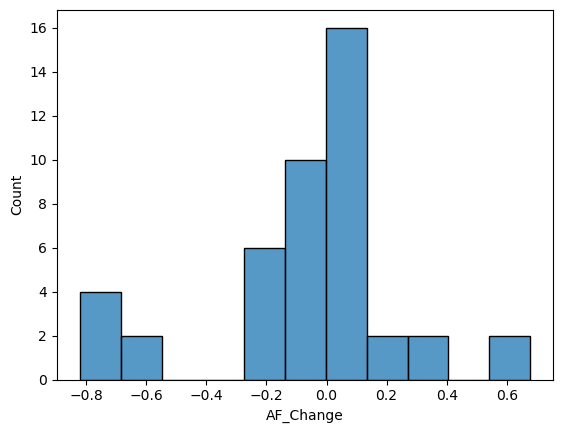

In [189]:
sns.histplot(data=df_longitudinal_phase_variants,
             x='AF_Change'
            )

In [238]:
df_sorted = df_longitudinal_phase_variants.sort_values(['pid', 'Sampling_Week'])

df_sorted['order'] = df_sorted.groupby(['pid', 'Variant']).cumcount() + 1

df_wide = df_sorted.pivot(index=['pid', 'Variant'], columns='order', values='AF')

df_wide.columns = ['AF_1', 'AF_2']
df_wide = df_wide.reset_index()

In [191]:
thresh = 0
print(len(df_longitudinal_phase_variants.query("Abs_AF_Change >= @thresh")))

df_longitudinal_phase_variants.query("Abs_AF_Change >= @thresh").drop_duplicates(subset=['pid', 'POS', 'REF']).AF_Change.mean()

44


-0.0603780605876591

In [242]:
st.ttest_rel(df_wide['AF_1'],
             df_wide['AF_2'],
             alternative='greater'
            )

TtestResult(statistic=0.8155863796172736, pvalue=0.21217191490875614, df=20)

In [192]:
st.wilcoxon(df_longitudinal_phase_variants.query("Abs_AF_Change >= @thresh").drop_duplicates(subset=['pid', 'POS', 'REF'])['AF_Change'],
            alternative='less'
           )

WilcoxonResult(statistic=114.0, pvalue=0.48642921447753906)

In [611]:
# for i, row in df_indels_H37Rv_all.dropna(subset='Gene1').query("phase_variant==1 & AF_Adj >= @AF_min & AF_Adj <= @AF_max & (Gene1.str.contains('|'.join(@full_genes_list)) | Gene2.str.contains('|'.join(@full_genes_list)))").iterrows():
for i, row in df_indels_H37Rv_all.query("(Gene1 in @full_genes_list | Gene2 in @full_genes_list) & AF_Adj >= @AF_min & AF_Adj <= @AF_max").sort_values("Region").iterrows():
    
    pid = row['pid']
    sampling_week = row['Sampling_Week']
    sample = row['SampleID']

    gene_1 = row['Gene1']
    gene_2 = row['Gene2']
    
    if len(df_trust_patients.query("pid==@pid & SampleID != @sample & F2 <= @F2_max")) > 0:
        other_sample = df_trust_patients.query("pid==@pid & SampleID != @sample & F2 <= @F2_max").SampleID.values[0]
        
        if len(df_indels_H37Rv_all.query("phase_variant==1 & Region==@region & SampleID==@other_sample & F2 <= @F2_max")) == 0:
            other_AF = 0
        else:
            other_AF = df_indels_H37Rv_all.query("phase_variant==1 & Region==@region & SampleID==@other_sample & F2 <= @F2_max").AF_Adj.values[0]
            
        other_week = df_trust_patients.query("pid==@pid & SampleID != @sample & F2 <= @F2_max").Sampling_Week.values[0]
            
    else:
        other_AF = np.nan
        other_week = np.nan
        
    print(pid, row['Coll2014'], gene_1, gene_2, row['POS'], row['REF'], row['ALT'], sampling_week, other_week, row['AF_Adj'], other_AF)

T0332 2.2.1.1 Rv1990A mazF6 2234247 C CG 1 8 0.0728155339805825 0
T0475 2.2.1.1 Rv3848 espR 4323354 C CG 1 6 0.7058823529411765 0
T0090 2.2.1.1 Rv3848 espR 4323354 C CG 1 6 0.3154121863799283 0
T0175 4.3.2.1 Rv0759c Rv0760c 854252 GC G 4 1 0.1019830028328611 0
T0217 2.2.1.1 Rv0759c Rv0760c 854252 GC G 1 5 0.4128440366972477 0
T0217 2.2.1.1 Rv0759c Rv0760c 854252 GC G 5 1 0.2462686567164179 0
T0222 4.3.2.1 Rv0759c Rv0760c 854252 GC G 7 1 0.1636904761904762 0
T0408 4.3.4.2.1 Rv0759c Rv0760c 854252 GC G 1 6 0.8693877551020408 0
T0409 4.3.4.2.1 Rv0759c Rv0760c 854252 GC G 4 1 0.8333333333333334 0
T0412 4.1.1.3 Rv0759c Rv0760c 854252 GC G 8 1 0.7352941176470589 0
T0355 4.3.3 Rv0759c Rv0760c 854252 G GC 1 8 0.0724137931034482 0
T0052 2.2.1.1 Rv0759c Rv0760c 854252 GC G 1 6 0.9455252918287936 0
T0007 2.2.1 Rv0759c Rv0760c 854252 GC G 1 nan 0.9396825396825396 nan
T0294 2.2.1.1 Rv0759c Rv0760c 854252 GC G 5 1 0.9417808219178082 0
T0267 4.3.2.1 Rv0759c Rv0760c 854250 C CG 6 nan 0.894444444444444